<a href="https://colab.research.google.com/github/VildanaRazumova/thesis-demand-forecasting/blob/main/thesis_notebook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand-Driven Load Factor Forecasting for Dynamic Pricing in B2B Charter Tourism

---

# The following Project information



**Client:** A leading B2B tour operator in Kazakhstan and Central Asia, cooperating with 5,000+ travel agencies across destinations including Vietnam, Thailand, Egypt, Turkey, UAE and the Maldives

**Problem statement & Importance:**
Tour operators in B2B travel markets must commit to flight and hotel inventory 6-8 months in advance, without knowing the actual demand. Traditional demand estimation methods rely on historical bookings and expert judgment, which becomes insufficient when market conditions shift due to competitor pricing, seasonal search trends, and external events. This uncertainty leads to either unsold seats or missed revenue opportunities. A critical business challenge is not only whether demand can be predicted accurately, but also how early in the booking window a reliable prediction can be made, giving the operator enough time to act.

**Goal:**
This study focuses on the Kazakhstan - Vietnam route as a pilot, as Vietnam is the operator's most popular destination and each route has unique demand patterns, seasonality, and external signals.


**Methodology:**
The methodology is designed to be scalable and applicable to other destinations in subsequent research.

The primary objective is to develop and evaluate machine learning models that predict flight load factor at multiple booking windows (D-90, D-60, D-30), using a multivariate feature set constructed from internal booking signals at each point in time.

The study additionally assesses whether external market signals improve prediction accuracy beyond internal booking data alone, and identifies the earliest booking window at which reliable load factor predictions can be made to support dynamic pricing decisions.

**Business Benefits:**
1. Identifies the earliest reliable prediction window
2. Reduces financial risk from unsold charter seats
3. Provides a data-driven foundation for dynamic price decisions
4. Competitive advantage over operators using rule-based pricing only

**Relevant data collected from:**

Historical Internal signals (2024-2026):
-  booking claims: lead time, pax, hotel & flight costs
-  flight capacity: seats sold, empty seats, load factor per window

External signals at specific points in the past:
- Google Trends API: search interest per destination
- Google News API: news per country
- Public holiday calendars: event & holiday flags

**Approach:**

A time-series approach is used throughout this project. Features are constructed at each booking window using only information available at that point in time, preventing data leakage and ensuring realistic future deployment.

**Core Task: Plan Completion Prediction at Multiple Booking Windows**

| Window | Days Before Departure | Business Meaning |
|--------|----------------------|------------------|
| D-90 | 90 days | Early signal: low booking activity |
| D-60 | 60 days | Demand trends become informative |
| D-30 | 30 days | Target window — majority of bookings visible

Two experiments are conducted:
- Baseline model: internal booking features only (Linear Regression, median predictor)
- Extended model: internal + external demand signals (Random Forest, XGBoost, LightGBM)

# Project Pipeline

This project will be approached through the following steps:

1. **Importing the Libraries**: loading all required Python packages
   for data analysis, visualisation and machine learning

2. **Importing the Data**: loading claims and flight load history
   datasets from Google Drive

3. **Claims Data Overview & Flights Data Overview**: understanding the structure, shape, date ranges
   and column descriptions of both datasets

4. **Exploratory Data Analysis (EDA)**: analysing demand patterns,
   seasonality, lead time distribution and booking window behaviour
   for Vietnam routes

5. **Data Preprocessing**: filter by departure date, route match, quality filters

6. **Joint Analysis and Booking Curve Reconstruction**: linking
   booking records to flights and reconstructing cumulative
   demand states at each booking window

7. **Feature Construction**: building internal and external
   features aligned with each booking window

8. **Chronological Splitting and Feature Selection**: splitting
   data by departure date to prevent data leakage

9. **Model Building**: training baseline and extended models
   across four booking windows

10. **Model Evaluation**: comparing model performance across booking
   windows using MAPE, MAE, RMSE and R2

11. **Conclusion** identifying the earliest booking window at which the model achieves reliable load factor predictions, quantifying the improvement from adding external signals, and discussing implications for dynamic pricing decisions in B2B charter tourism.

# 1. Importing the Libraries

In [567]:
# Import Libraries
from google.colab import drive

# Data libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pandas.plotting import autocorrelation_plot

# Machine Learning
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import lightgbm as lgb

# 2. Import the Data

In [568]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Claims

In [569]:
df_claims = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_claims_features.csv'
)

In [570]:
df_claims.head(3)

,snapshot_date,snapshot_ts_utc,ClaimID,TourID,StatusID,StatusName,IsCancelled,ClaimCreatedDT_UTC,raw_event_time_utc,DepartureDT,...,FlightPartnerID_Fwd,FlightPartner_Fwd,FlightPartnerID_Bck,FlightPartner_Bck,FlightCost_Fwd,FlightCost_Bck,RevisionAmount_Fwd,RevisionAmount_Bck,CurrencyClaimID,CurrencyAlias
0,2026-03-17,2026-03-17 16:54:25,8211917,23966,1,Paid,0,2024-05-21 11:00:00,2024-05-21 11:00:00,2024-08-01,...,157575,SCAT,157575,SCAT,944.16,704.16,120.0,0.0,2,USD
1,2026-03-17,2026-03-17 16:54:25,8456807,23966,1,Paid,0,2024-07-19 10:52:00,2024-07-19 10:52:00,2024-08-01,...,157575,SCAT,157575,SCAT,974.16,704.16,135.0,0.0,2,USD
2,2026-03-17,2026-03-17 16:54:25,8433696,23966,1,Paid,0,2024-07-14 14:59:00,2024-07-14 14:59:00,2024-08-03,...,194333,VietJet,194333,VietJet,1726.52,776.52,475.0,0.0,2,USD


### Load Flights

In [571]:
df_flights = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_flight_load_history.csv',
    on_bad_lines='skip'
)

In [572]:
df_flights.head(3)

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,IsReturn,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,...,IsOnRequest,Seats_gross,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp
0,2026-03-17,2026-03-17 16:54:53,10670,VSV5208,2024-01-01,1,157575,SCAT (),2,Y,...,0,183,2,181,183,2,1,157,1,46013423911
1,2026-03-17,2026-03-17 16:54:53,11538,VJ61,2024-01-01,1,194333,VietJet Air,2,Y,...,0,30,0,30,30,0,1,137,1,46010971579
2,2026-03-17,2026-03-17 16:54:53,12523,VSV5319,2024-01-01,1,157575,SCAT (),2,Y,...,0,30,6,24,30,6,1,52,1,46012591950


# 3.1. Claims Data Overview

1. General Overview
2. Data types
3. Check duplicates
4. Booking Status Distribution
5. Basic Statistics

In [573]:
# 1. General Overview
print(f'Rows: {df_claims.shape[0]:,}')
print(f'Columns: {df_claims.shape[1]}')
print(f'Booking date: {df_claims["ClaimCreatedDT_UTC"].min()} - {df_claims["ClaimCreatedDT_UTC"].max()}')
print(f'Departure: {df_claims["DepartureDT"].min()} - {df_claims["DepartureDT"].max()}')
print(f'Destination: {df_claims["CountryName"].unique()}')
print(f'Missing: {df_claims.isnull().sum().sum()}')

Rows: 37,674
Columns: 64
Booking date: 2023-09-05 11:57:00 - 2026-03-04 08:15:00
Departure: 2024-01-01 - 2026-03-05
Destination: ['Vietnam']
Missing: 145


In [574]:
# Misssing Values in details
df_claims.isnull().sum()[df_claims.isnull().sum() > 0]

,0
HotelName,29
MealName,29
RoomTypeName,29
AccommodationName,29
HotelRegion,29


In [575]:
df_claims[df_claims['HotelName'].isnull()]['TourTypeName'].value_counts()

,count
TourTypeName,
Dynamic package,24
Beach Tours,5


In [576]:
# Check booked AFTER departure
print(f"Negative lead times: {(df_claims['LeadTimeDays'] < 0).sum()}")
print(f"Zero lead times: {(df_claims['LeadTimeDays'] == 0).sum()}")

Negative lead times: 0
Zero lead times: 27


In [577]:
# 2. Data types
df_claims.dtypes

,0
snapshot_date,object
snapshot_ts_utc,object
ClaimID,int64
TourID,int64
StatusID,int64
...,...
FlightCost_Bck,float64
RevisionAmount_Fwd,float64
RevisionAmount_Bck,float64
CurrencyClaimID,int64


In [578]:
# 3. Check duplicates
print(f'Duplicate ClaimIDs:  {df_claims["ClaimID"].duplicated().sum()}')
print(f'Duplicate rows:      {df_claims.duplicated().sum()}')

Duplicate ClaimIDs:  0
Duplicate rows:      0


In [579]:
# 4. Booking Status Distribution
print(df_claims['StatusName'].value_counts())

StatusName
Paid      37665
Unpaid        9
Name: count, dtype: int64


In [580]:
print(df_claims['IsCancelled'].value_counts())

IsCancelled
0    37674
Name: count, dtype: int64


In [581]:
# 5. Basic Statistics
print(df_claims[['LeadTimeDays', 'TourNights', 'Padult', 'Pchild',
                  'HotelCost', 'FlightCost_Fwd', 'FlightCost_Bck',
                  'RevisionAmount_Fwd']].describe().round(2))

       LeadTimeDays  TourNights    Padult    Pchild  HotelCost  \
count      37674.00    37674.00  37674.00  37674.00   37674.00   
mean          47.19        9.27      2.17      0.28     991.23   
std           39.58        2.18      0.79      0.58    1055.96   
min            0.00        2.00      1.00      0.00       0.00   
25%           16.00        8.00      2.00      0.00     329.46   
50%           36.00        9.00      2.00      0.00     672.70   
75%           69.00       11.00      2.00      0.00    1253.87   
max          255.00      105.00     10.00      6.00   16063.42   

       FlightCost_Fwd  FlightCost_Bck  RevisionAmount_Fwd  
count        37674.00        37674.00            37674.00  
mean           919.83          963.68              -28.34  
std            804.21          430.90              226.34  
min           -750.40            0.00            -1060.00  
25%            484.68          732.62             -145.00  
50%            748.62          817.70        

In [582]:
print(df_claims['CurrencyAlias'].value_counts())

CurrencyAlias
USD    37674
Name: count, dtype: int64


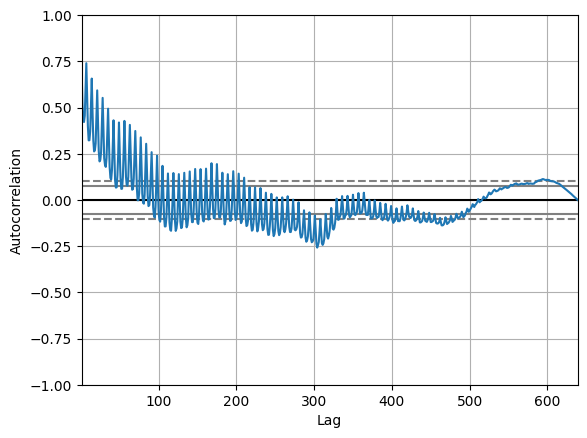

In [583]:
# Autocorrelation & Seasonality Check

df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])

daily = (df_claims
         .set_index('ClaimCreatedDT_UTC')
         .resample('D')
         .size()
         ['2024-06-01':'2026-03-01'])

autocorrelation_plot(daily)
plt.show()

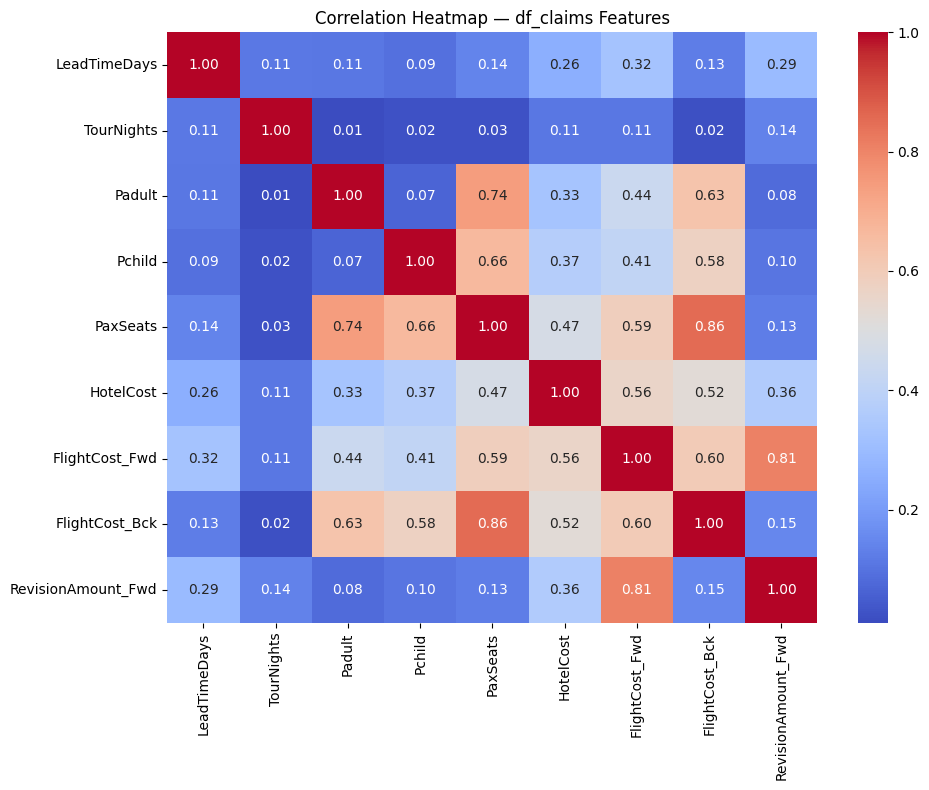

In [584]:
# Correlation heatmap claims
cols_claims = [
    'LeadTimeDays',
    'TourNights',
    'Padult',
    'Pchild',
    'PaxSeats',
    'HotelCost',
    'FlightCost_Fwd',
    'FlightCost_Bck',
    'RevisionAmount_Fwd'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_claims[cols_claims].corr(method='spearman'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — df_claims Features')
plt.tight_layout()
plt.show()

The claims dataset contains **37 674 rows** and **64 columns**, covering the departure period from **January 2024 to March 2026**. Each row should represent a single tour package claim for the destination **Vietnam**, created by a travel agency on behalf of an end customer.

Pearson correlation analysis reveals several multicollinear features in df_claims. These pairs will be addressed during feature selection to avoid multicollinearity in the model.

The dataset includes the following key information:
- **Booking behaviour:** claim creation date, departure date, lead time
  in days, tour duration, number of nights
- **Passengers:** number of adults, children, and infants per booking
- **Product details:** hotel name, star rating, meal plan, room type,
  accommodation type, hotel region
- **Pricing:** hotel cost, flight cost (forward and return),
  total hotel cost, revision amounts
- **Flight information:** departure and arrival cities, flight class,
  airline partner, freight IDs

**Data Quality:**
- Missing values: 145
- Duplicate ClaimIDs: 0
- Duplicate rows: 0
- Currency: all USD
- No cancellations, this dataset contains only active bookings.

**Data Concerns:**
- 29 missing values in hotel-related fields all belong to the all belong to Dynamic Package and Beach Tours. Will be excluded from model training because the tour package should include hotel + flight.
- 27 zero lead time bookings claims created on the same day as departure. Will be excluded from model training.
- 9 Unpaid claims will be excluded from this model training.

# 3.2. Flights Data Overview

1. General Overview
2. Data Types
3. Duplicate Check
4. Basic Statistics
5. Airlines & Routes Distribution
6. Load Factor

In [585]:
# 1. General Overview
print(f'Rows: {df_flights.shape[0]:,}')
print(f'Columns: {df_flights.shape[1]}')
print(f'BlockDate: {df_flights["BlockDate"].min()} - {df_flights["BlockDate"].max()}')
print(f'Missing: {df_flights.isnull().sum().sum()}')

Rows: 4,015
Columns: 32
BlockDate: 2024-01-01 - 2026-03-05
Missing: 0


In [586]:
# 2. Data types
df_flights.dtypes

,0
snapshot_date,object
snapshot_ts_utc,object
FreightID,int64
FlightName,object
BlockDate,object
IsReturn,int64
AirlinePartnerID,int64
AirlineName,object
FlightClassID,int64
ClassAlias,object


In [587]:
# 3. Duplicate Check
print(f'Duplicate FreightIDs: {df_flights["FreightID"].duplicated().sum()}')
print(f'Duplicate rows:       {df_flights.duplicated().sum()}')

Duplicate FreightIDs: 3930
Duplicate rows:       0


In [588]:
# 4. Basic statistics
print(df_flights[['Seats_gross', 'Sold_net', 'Empty',
                   'TotalDaysInSale']].describe().round(2))

       Seats_gross  Sold_net    Empty  TotalDaysInSale
count      4015.00   4015.00  4015.00          4015.00
mean         63.25     48.20    12.97           156.71
std          42.39     41.68    31.44            60.05
min           1.00      0.00     0.00          -167.00
25%          30.00     20.00     0.00           115.00
50%          45.00     40.00     0.00           156.00
75%          91.00     64.00     3.00           202.00
max         364.00    344.00   183.00           297.00


In [589]:
#5. Airlines & Routes Distribution
print(df_flights['AirlineName'].value_counts())

AirlineName
SCAT ()                               1797
Air Astana ()                         1164
VietJet Air                            722
Qanot Sharq                            301
Selfie Travel (Селфи Тревел) ТОО        23
Pegas Kazakhstan (ПЕГАС КАЗАХСТАН)       3
Touroperator KOMPAS                      2
Selfie tour                              1
Crystal Bay Kazakhstan                   1
ANEX Tourism Worldwide DMCC              1
Name: count, dtype: int64


In [590]:
# Clean brackets from raw data
df_flights['AirlineName'] = df_flights['AirlineName'].str.replace(
    r'\s*\(.*?\)', '', regex=True
).str.strip()

In [591]:
df_flights['Route'] = df_flights['CityFrom'] + ' -> ' + df_flights['CityTo']
print(df_flights['Route'].value_counts())

Route
Almaty -> Cam Ranh      582
Cam Ranh -> Almaty      564
Almaty -> Phu Quoc      453
Phu Quoc -> Almaty      452
Cam Ranh -> Astana      335
Astana -> Cam Ranh      335
Phu Quoc -> Astana      274
Astana -> Phu Quoc      273
Astana -> Da Nang        81
Da Nang -> Astana        80
Phu Quoc -> Tashkent     78
Tashkent -> Phu Quoc     77
Tashkent -> Cam Ranh     75
Cam Ranh -> Tashkent     74
Almaty -> Da Nang        74
Da Nang -> Almaty        72
Phu Quoc -> Shymkent     29
Shymkent -> Phu Quoc     28
Phu Quoc -> Aktobe       13
Phu Quoc -> Kostanay     13
Phu Quoc -> Ural`sk      13
Kostanay -> Phu Quoc     13
Aktobe -> Phu Quoc       13
Ural`sk -> Phu Quoc      13
Phuket -> Phu Quoc        1
Name: count, dtype: int64


In [592]:
print(df_flights['Country'].value_counts())

Country
Vietnam       2018
Kazakhstan    1845
Uzbekistan     152
Name: count, dtype: int64


In [593]:
# 6. Load Factor - the percentage of available seats that were sold on a flight.
df_flights['LoadFactor'] = (df_flights['Sold_gross'] / df_flights['Seats_gross'] * 100).round(2)
print(df_flights['LoadFactor'].describe().round(2))

count    4015.00
mean       78.26
std        39.24
min         0.00
25%        93.33
50%       100.00
75%       100.00
max       100.00
Name: LoadFactor, dtype: float64


In [594]:
print(df_flights.groupby('AirlineName')['LoadFactor'].mean().round(2).sort_values(ascending=False))

AirlineName
Touroperator KOMPAS            100.00
Air Astana                      99.03
SCAT                            78.13
Qanot Sharq                     73.64
VietJet Air                     49.25
Selfie Travel ТОО               26.09
ANEX Tourism Worldwide DMCC      0.00
Pegas Kazakhstan                 0.00
Crystal Bay Kazakhstan           0.00
Selfie tour                      0.00
Name: LoadFactor, dtype: float64


In [595]:
# Check negative TotalDaysInSale
print(df_flights[df_flights['TotalDaysInSale'] < 0]['TotalDaysInSale'].describe())
print(f"\nCount: {(df_flights['TotalDaysInSale'] < 0).sum()}")

count      1.0
mean    -167.0
std        NaN
min     -167.0
25%     -167.0
50%     -167.0
75%     -167.0
max     -167.0
Name: TotalDaysInSale, dtype: float64

Count: 1


In [596]:
df_flights[df_flights['TotalDaysInSale'] < 0]

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,IsReturn,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,...,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp,Route,LoadFactor
1248,2026-03-17,2026-03-17 16:54:53,13060,HH-2232,2024-03-08,1,195161,Qanot Sharq,2,Y,...,0,30,30,0,1,-167,1,38293143059,Cam Ranh -> Tashkent,0.0


In [597]:
print(df_flights['IsReturn'].value_counts())

IsReturn
0    2018
1    1997
Name: count, dtype: int64


The flight load history dataset contains **4 015 rows** and **32 columns**,
covering charter flight blocks operated on Kazakhstan -> Vietnam and Vietnam -> Kazakhstan routes, from **January 2024 to March 2026**.

Each row represents a single charter flight block assigned to the
operator, containing capacity and sales information at the time of
the data snapshot.

The dataset includes the following key information:
- **Flight details:** flight name, block date, airline partner,
  departure and arrival cities, flight class
- **Capacity:** gross seats available, net seats available
- **Demand signals:** seats sold (gross and net), empty seats,
  total days in sale
- **Operational flags:** hard block indicator, stop sale flag,
  on-request flag, release days

**Data Quality:**
- Missing values: **None detected**
- Duplicate rows: **0**
- Duplicate FreightIDs: **3,930** expected, as the same flight in different days

**Routes Distribution:**
- Main routes: Almaty - Cam Ranh, Almaty - Phu Quoc,
  Astana - Cam Ranh, Astana - Phu Quoc
- Countries covered: Vietnam, Kazakhstan, Uzbekistan

**TOP 3 Airlines:**
- SCAT
- Air Astana
- VietJet Air

**Data Concerns:**

- 152 Uzbekistan routes excluded, only Kazakhstan -> Vietnam direction is relevant for the model.
- LF = 0% (488 flights) flagged likely future flights or stopped sales, will be reviewed in EDA.
- LF = 100% (2,665 flights) the majority of flights are fully sold out, will be reviewed in EDA.
- 1 flight with TotalDaysInSale = -167 (Cam Ranh -> Tashkent), data error, excluded together with Uzbekistan routes.
- LoadFactor cannot be used as model target due to right-censoring: 82% of flights achieve LF = 100%.

TotalDaysInSale and days_to_first_reserve show perfect correlation (1.00), one will be excluded from the model to avoid multicollinearity. Flight-level features show weak correlation with LoadFactor (max 0.17), confirming that the main predictive signal will come from cumulative booking data reconstructed from claims.

**IMPORTANT!** No as-of (point-in-time) snapshots available, cumulative booking state at each window (D-90, D-60, D-30, D-7) will be reconstructed from claims data in the preprocessing step.

 # 4. Exploratory Data Analysis (EDA)

1. EDA for df_claims
2. EDA for df_flights

### 1) EDA for df_claims

1. Lead Time Distribution
2. Booking Pace Over Time
3. Seasonality Patterns
4. Price Distribution
5. PaxSeats
6. Top hotels / regions

#### 1. Lead Time Distribution

Lead time is the number of days between the booking creation
date and the departure date.

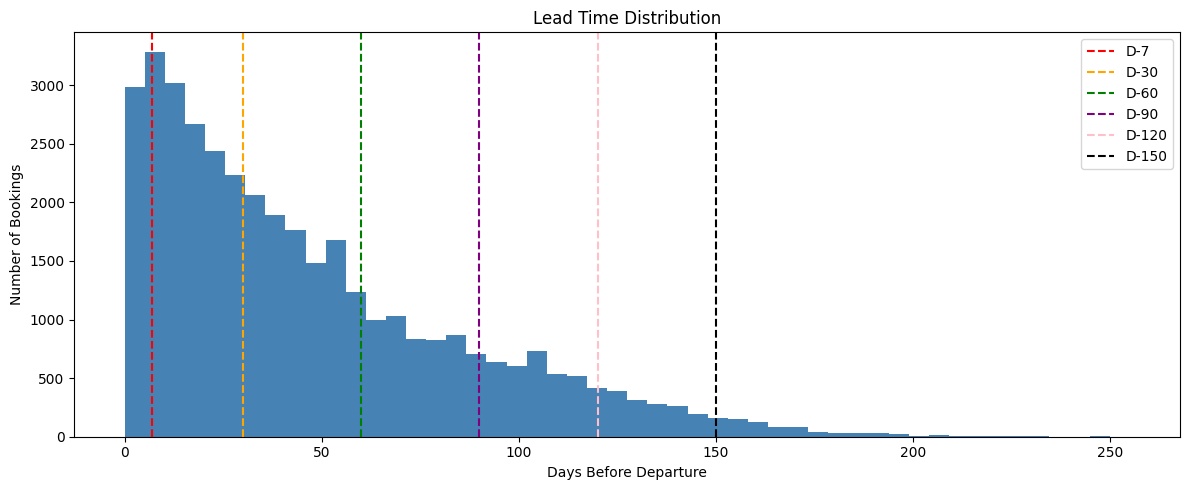

In [598]:
# Figure 1: Lead Time Distribution

# Step 1: Filter out LeadTimeDays = 0
claims_plt = df_claims['LeadTimeDays']

# Step 2: Create the histogram
plt.figure(figsize=(12, 5))
plt.hist(claims_plt, bins=50, color='steelblue')

# Step 3: Add vertical lines for each booking window
plt.axvline(x=7,  color='red',    linestyle='--', label='D-7')
plt.axvline(x=30, color='orange', linestyle='--', label='D-30')
plt.axvline(x=60, color='green',  linestyle='--', label='D-60')
plt.axvline(x=90, color='purple', linestyle='--', label='D-90')
plt.axvline(x=120, color='pink', linestyle='--', label='D-120')
plt.axvline(x=150, color='black', linestyle='--', label='D-150')

# Step 4: Add labels and title
plt.title('Lead Time Distribution')
plt.xlabel('Days Before Departure')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

In [599]:
# % of bookings days before departure
for d in [7, 30, 60, 90, 120]:
    pct = (claims_plt >= d).sum() / len(claims_plt) * 100
    print(f"Booked by D-{d}: {pct:.1f}%")

Booked by D-7: 90.4%
Booked by D-30: 56.9%
Booked by D-60: 30.3%
Booked by D-90: 15.8%
Booked by D-120: 6.7%


#### 2. Booking Pace Over Time

Booking pace shows how many tour packages were booked per month.

In [600]:
# Convert to datetime
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])
df_claims['DepartureDT'] = pd.to_datetime(df_claims['DepartureDT'])

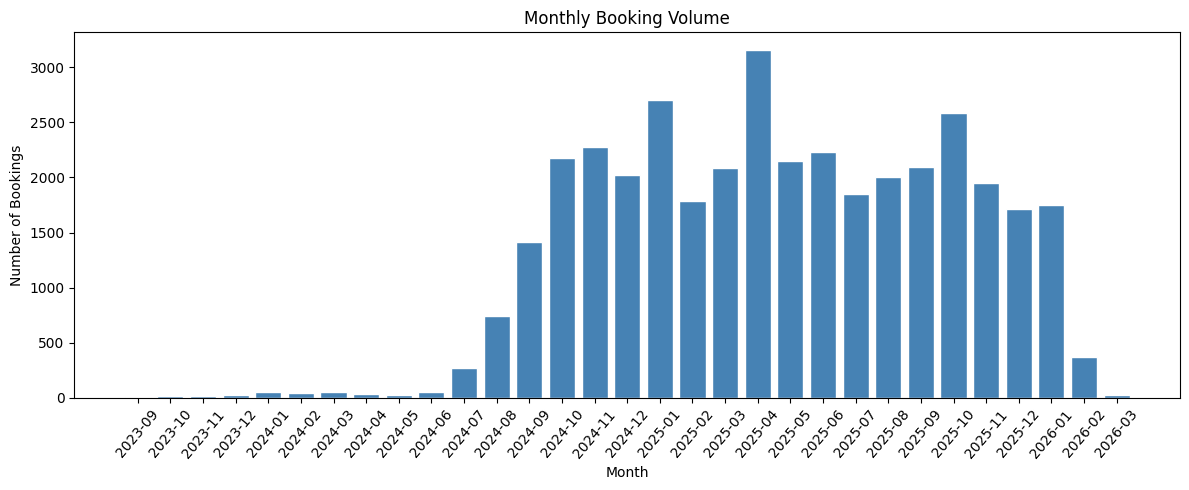

In [601]:
# Figure 2: Monthly Booking Volume

# Step 1: Extract the month from the booking date
df_claims['BookingMonth'] = df_claims['ClaimCreatedDT_UTC'].dt.to_period('M')

# Step 2: Count how many bookings happened in each month
monthly_active = df_claims.groupby('BookingMonth').size().reset_index(name='Bookings')

# Step 3: Draw the bar chart per month
plt.figure(figsize=(12, 5))
plt.bar(monthly_active['BookingMonth'].astype(str), monthly_active['Bookings'],
        color='steelblue', edgecolor='white')
plt.title('Monthly Booking Volume')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

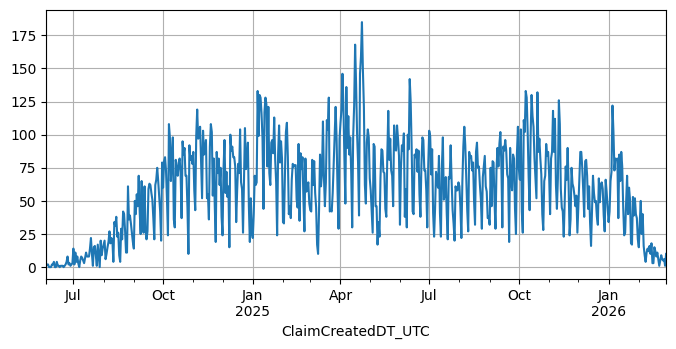

In [602]:
df_claims_ts = df_claims.set_index('ClaimCreatedDT_UTC').sort_index()

# Count bookings per day
daily = df_claims_ts['2024-06-01':'2026-03-01'].resample('D').size()
daily.plot(grid=True, figsize=(8, 3.5))
plt.show()

### 3. Seasonality Patterns

Seasonality analysis examines which months have the highest booking demand for Vietnam routes.

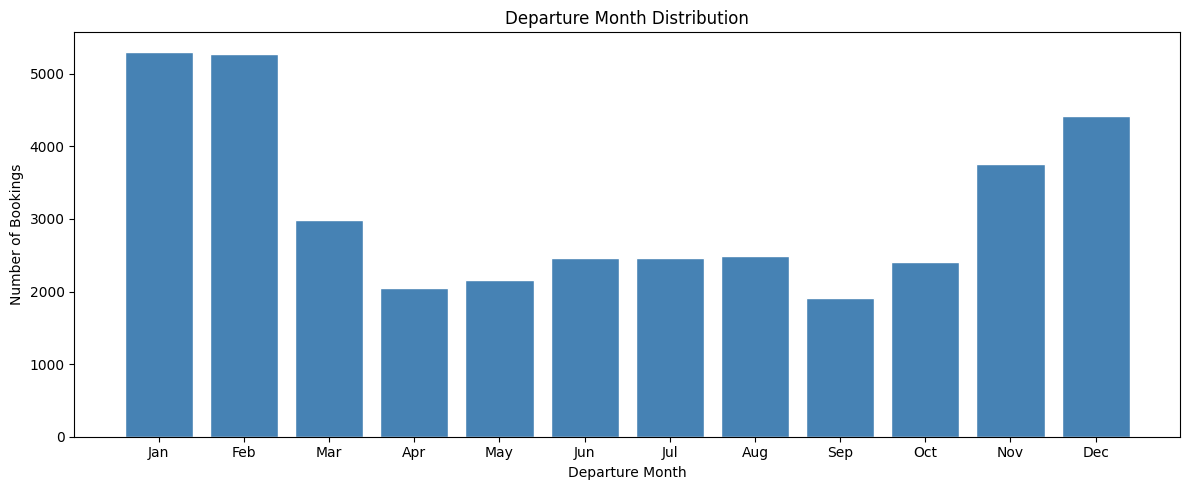

In [603]:
# Figure 3: Departure Month Distribution

# Step 1: Extract departure month
df_claims['DepartureMonth'] = df_claims['DepartureDT'].dt.month

# Step 2: Month names for readable format
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']

# Step 3: Count how many bookings happened in each month
monthly_dep = df_claims.groupby('DepartureMonth').size()

# Step 4: Plot
plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_dep.values,
    color='steelblue', edgecolor='white')
plt.title('Departure Month Distribution')
plt.xlabel('Departure Month')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

### 4. Price Distribution

Price distribution analysis examines the spread of flight and hotel
costs across all bookings. This helps identify outliers, understand
pricing segments and prepare the Price Ratio feature for modelling.

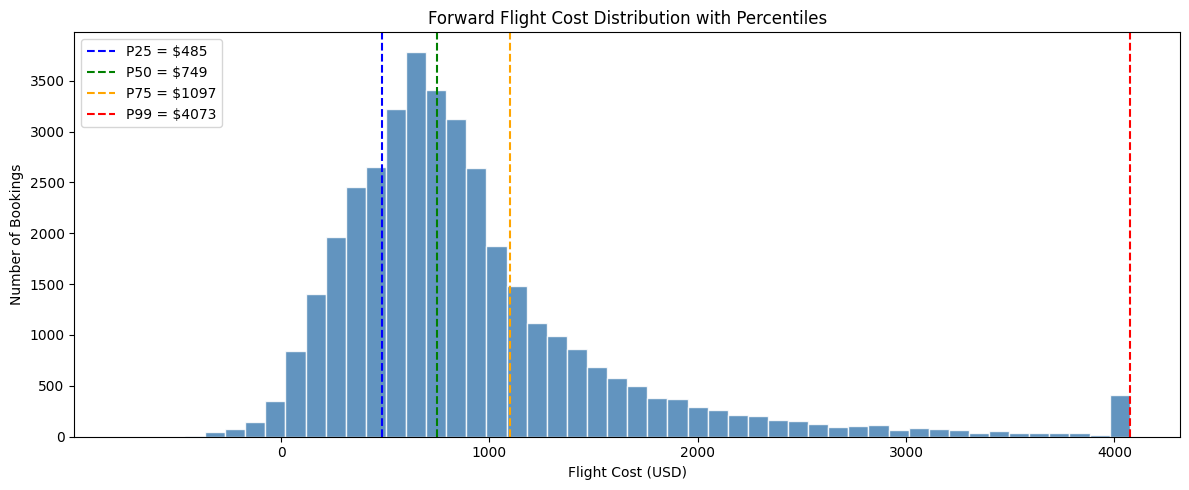

In [604]:
# Figure 4: Flight Cost Distribution

# Step 1: Calculate key percentiles
p25 = df_claims['FlightCost_Fwd'].quantile(0.25)
p50 = df_claims['FlightCost_Fwd'].quantile(0.50)
p75 = df_claims['FlightCost_Fwd'].quantile(0.75)
p99 = df_claims['FlightCost_Fwd'].quantile(0.99)

# Step 2: Plot histogram
plt.figure(figsize=(12, 5))
plt.hist(df_claims['FlightCost_Fwd'].clip(upper=p99),
        bins=50,
        color='steelblue',
        edgecolor='white',
        alpha=0.85)

# Step 3: Add vertical lines for each percentile
plt.axvline(x=p25, color='blue',   linestyle='--',
          linewidth=1.5, label=f'P25 = ${p25:.0f}')
plt.axvline(x=p50, color='green',  linestyle='--',
          linewidth=1.5, label=f'P50 = ${p50:.0f}')
plt.axvline(x=p75, color='orange', linestyle='--',
          linewidth=1.5, label=f'P75 = ${p75:.0f}')
plt.axvline(x=p99, color='red',    linestyle='--',
          linewidth=1.5, label=f'P99 = ${p99:.0f}')

# Step 4: Add labels and title
plt.title('Forward Flight Cost Distribution with Percentiles')
plt.xlabel('Flight Cost (USD)')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()


In [605]:
# Count anomalies
print(f'Negative flight costs: {(df_claims["FlightCost_Fwd"] < 0).sum()}')
print(f'Zero flight costs:     {(df_claims["FlightCost_Fwd"] == 0).sum()}')

Negative flight costs: 500
Zero flight costs:     3


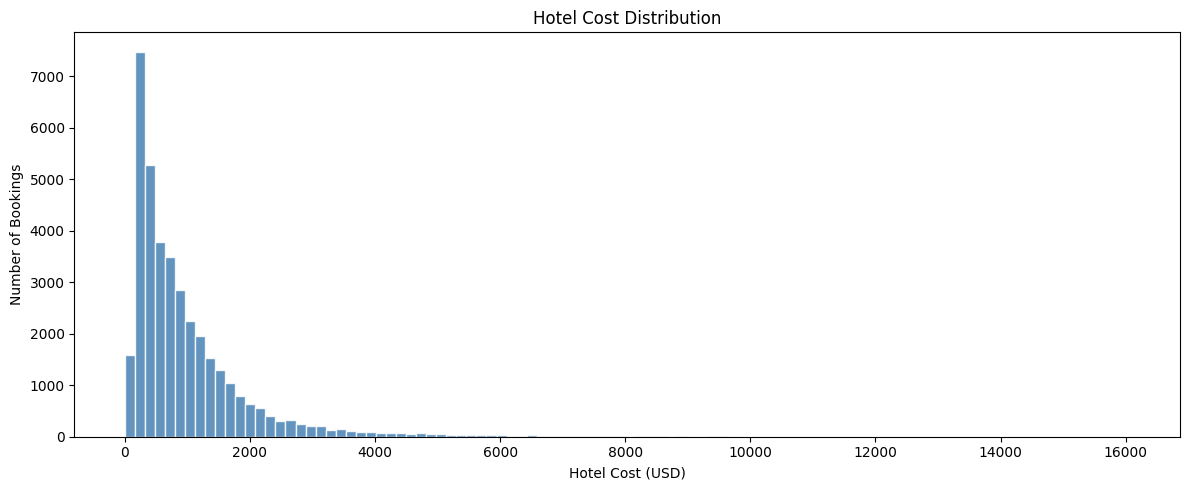

In [606]:
# Figure 4: Hotel Cost Distribution

# Step 1: Plot histogram with ALL hotel cost values
plt.figure(figsize=(12, 5))
plt.hist(df_claims['HotelCost'], bins=100,
    color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Hotel Cost Distribution')
plt.xlabel('Hotel Cost (USD)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

In [607]:
# HotelCost statistics
print(df_claims['HotelCost'].describe().round(2))

count    37674.00
mean       991.23
std       1055.96
min          0.00
25%        329.46
50%        672.70
75%       1253.87
max      16063.42
Name: HotelCost, dtype: float64


In [608]:
# Zero and negative values
print('\nZero hotel cost:',
(df_claims['HotelCost'] == 0).sum())
print('Negative hotel cost:',
(df_claims['HotelCost'] < 0).sum())


Zero hotel cost: 14
Negative hotel cost: 0


### 5. PaxSeats
Passenger Group Size per Booking

In [609]:
print(df_claims['PaxSeats'].describe().round(2))

count    37674.00
mean         2.45
std          1.04
min          1.00
25%          2.00
50%          2.00
75%          3.00
max         11.00
Name: PaxSeats, dtype: float64


### 6. Top hotels / regions

In [610]:
# Top 10 hotels by booking volume
print(df_claims['HotelName'].value_counts().head(10))

HotelName
Wyndham Grand Phu Quoc                     2982
Wyndham Garden Grandworld Phu Quoc         1760
Queen Ann Nha Trang                        1627
Vinpearl Resort & Spa Phu Quoc             1264
Radisson Blu Resort Phu Quoc               1151
Premier Residences Phu Quoc Emerald Bay    1083
Sheraton Phu Quoc Long Beach Resort         974
Vinpearl Resort & Spa Nha Trang Bay         895
Aquamarine Resort Hotel Cam Ranh            764
Signature Hotel Nha Trang                   727
Name: count, dtype: int64


In [611]:
# Top regions
print(df_claims['HotelRegion'].value_counts())

HotelRegion
Phu Quoc      17789
Nha Trang     16553
Da Nang        2890
Hoyan           286
Phan Thiet      126
Khyue             1
Name: count, dtype: int64


# EDA for df_claims summary

1. **Lead Time Distribution**

Most bookings are made close to departure, only 15% of demand is visible at D-90. This confirms a late-booking market. However, for pricing decisions, the early window D-90 is most valuable to react and adjust prices effectively.

2. **Booking Pace Over Time**

Booking volume grew significantly from mid-2024 as this was a newly launched market. Therefore, model training will use data from 01.10.2024 to 28.02.2026 to capture real and stable demand patterns. From late 2025, monthly booking volume stabilised at around 1,700–2,000 bookings per month.

3. **Seasonality Patterns**

Peak departure months are January and February (5,300 bookings each), followed by December and November. The lowest demand is in September and April–May. This reflects a clear winter seasonality.

4. **Group Size Distribution**

PaxSeats median is 2, max is 11.

5. **Price Distribution**

Forward flight cost median is 749, with 25% paying over 1,097. Hotel cost median is 673, but the mean is 991 due to expensive outliers (max 16,063). 14 zero hotel cost bookings belong to Info Tours for agents and will be excluded.

6. **Top Hotels and Regions**

Phu Quoc (47%) and Nha Trang (44%) dominate demand. Da Nang represents only 8%. Wyndham Grand Phu Quoc is the most booked hotel with 2,982 bookings. HotelRegion will be an important feature for the model.

### 2) EDA for df_flights

1. Load Factor Distribution
2. Operational Flags
3. Sales Window Analysis
4. First reservation to departure
5. Flight Name Quality Check
6. Flight Cleaning
7. City Analysis
8. Flight Direction Analysis

###1. Load Factor Distribution
Load Factor is the percentage of available seats that were sold on a flight. It is the target variable of this study

/tmp/ipykernel_3924/1578286470.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


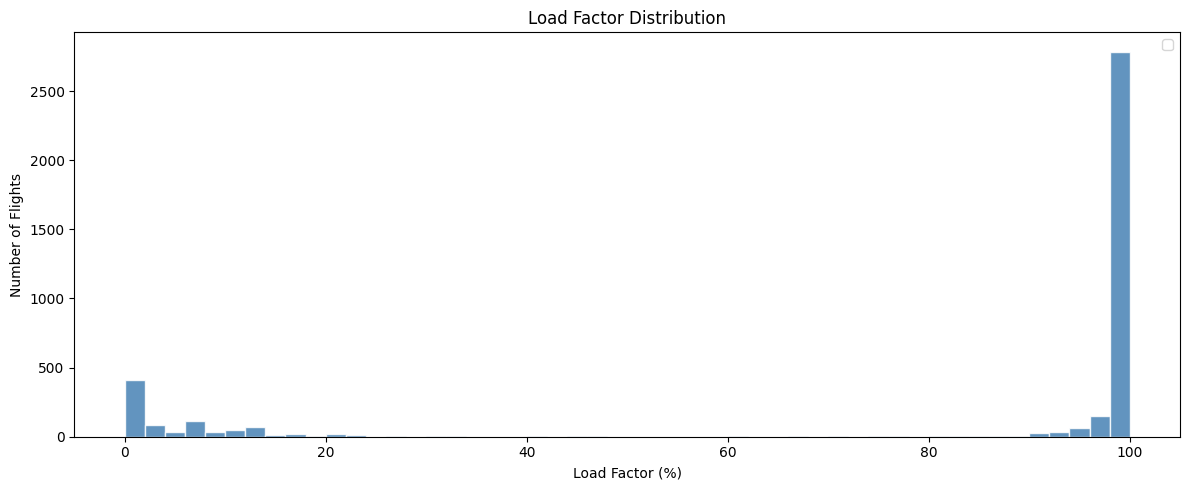

In [612]:
# Plot Load Factor distribution
plt.figure(figsize=(12, 5))
plt.hist(df_flights['LoadFactor'], bins=50,
         color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Load Factor Distribution')
plt.xlabel('Load Factor (%)')
plt.ylabel('Number of Flights')
plt.legend()
plt.tight_layout()
plt.show()

###2. Operational Flags

In [613]:
print(df_flights['HasStopSale'].value_counts())
print(df_flights['IsOnRequest'].value_counts())
print(df_flights['hard_block'].value_counts())
print(df_flights['ClassAlias'].value_counts())

HasStopSale
0    3512
1     503
Name: count, dtype: int64
IsOnRequest
0    4015
Name: count, dtype: int64
hard_block
1    4015
Name: count, dtype: int64
ClassAlias
Y    4015
Name: count, dtype: int64


### 3. Sales Window Analysis

In [614]:
print(df_flights['TotalDaysInSale'].describe().round(1))

count    4015.0
mean      156.7
std        60.1
min      -167.0
25%       115.0
50%       156.0
75%       202.0
max       297.0
Name: TotalDaysInSale, dtype: float64


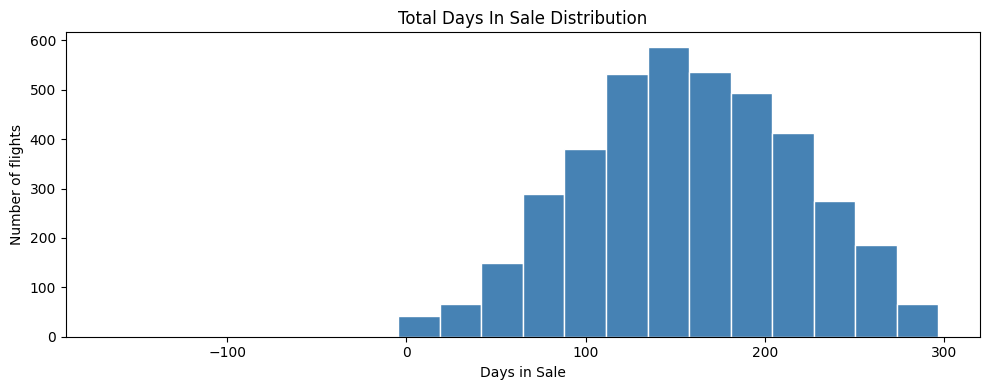

In [615]:
fig, ax = plt.subplots(figsize=(10, 4))
df_flights['TotalDaysInSale'].dropna().plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Days In Sale Distribution')
ax.set_xlabel('Days in Sale')
ax.set_ylabel('Number of flights')
plt.tight_layout()
plt.show()

### 4. First reservation to departure

In [616]:
# days from first reservation to departure
df_flights['first_reserve_utc'] = pd.to_datetime(df_flights['first_reserve_utc'])
df_flights['BlockDate'] = pd.to_datetime(df_flights['BlockDate'])

df_flights['days_to_first_reserve'] = (df_flights['BlockDate'] - df_flights['first_reserve_utc']).dt.days
print(df_flights['days_to_first_reserve'].describe().round(1))

count    4015.0
mean      155.7
std        60.1
min      -168.0
25%       114.0
50%       155.0
75%       201.0
max       296.0
Name: days_to_first_reserve, dtype: float64


### 5. Flight Name Quality Check

In [617]:
print(df_flights['FlightName'].unique())

['VSV5208' 'VJ61' 'VSV5319' 'VSV5333.' 'VSV5331..' 'VJ67' 'VSV5355'
 'VSV5251' 'VSV5335.' 'VSV5321.' 'VSV5253.' 'VSV5251.' 'VSV5207' 'VSV5318'
 'VSV5320.' 'VJ62' 'VSV5330..' 'VSV5332.' 'VSV5334.' 'VJ68' 'VSV5250...'
 'VSV5354' 'VSV5331.' 'KC162' 'VSV5339' 'VSV5321' 'VSV5317'
 'VSV5330íåàêò(ñìåíàðåéñîâ)' 'KC174' 'HH2234' 'KC161' 'VSV5320' 'VSV5338'
 'KC173' 'VSV5316' 'HH2233' 'VSV5331íåàêò(ñìåíàðåéñà)' 'KC158' 'KC194'
 'VSV5343' 'VJ61.' 'VSV5341' 'KC193' 'KC157' 'VSV5340' 'VSV5342' 'VSV5312'
 'VSV5308' 'VSV5331' 'VSV5302' 'VSV5337' 'VSV5313' 'VSV5330' 'VSV5309'
 'VSV5303' 'VSV5336' 'HH-2232' 'HH-2231' 'VSV5351' 'VSV5350' 'VJ67.'
 'VSV5339..' 'Test' 'VSV4444test' 'VSV5341.' 'KC260' 'HH-2238' 'VSV5340.'
 'HH-2237' 'KC259' 'VSV5208.' 'HH-2231.' 'KC600' 'KC599' 'VSV5351.'
 'VJ68.' 'VSV5315' 'VSV10000TEST' 'VSV5314' 'VSV9999TEST' 'VSV5354.'
 'VSV5319.' 'VZ8934' 'HH-2235' 'KC162.']


In [618]:
long_names = df_flights[df_flights['FlightName'].str.len() > 10]['FlightName'].unique()
print(long_names)

['VSV5330íåàêò(ñìåíàðåéñîâ)' 'VSV5331íåàêò(ñìåíàðåéñà)' 'VSV4444test'
 'VSV10000TEST' 'VSV9999TEST']


In [619]:
test_flights = df_flights[df_flights['FlightName'].str.lower().str.contains('test|fake', na=False)]['FlightName'].unique()
print(test_flights)

['Test' 'VSV4444test' 'VSV10000TEST' 'VSV9999TEST']


###6. Flight Cleaning

In [620]:
exclude_pattern = r'test|fake|íåàêò'

In [621]:
df_clean = df_flights[
    ~df_flights['FlightName'].str.contains(exclude_pattern, case=False, na=False) &
    (df_flights['TotalDaysInSale'] > 0) &
    (df_flights['CityFrom'] != 'Tashkent')
].copy()

In [622]:
# FreightID + BlockDate = unique flight on a specific date
print(f'Unique FreightIDs: {df_clean["FreightID"].nunique()}')
print(f'Unique FreightID + BlockDate: {df_clean.groupby(["FreightID", "BlockDate"]).ngroups}')

Unique FreightIDs: 74
Unique FreightID + BlockDate: 3818


In [623]:
print('-------- FreightID + BlockDate -----------')
print(f'Before:    {df_flights.groupby(["FreightID", "BlockDate"]).ngroups} flights')
print(f'After:    {df_clean.groupby(["FreightID", "BlockDate"]).ngroups} flights')

print('-------- FreightID -----------')
print(f'Before: {df_flights.FreightID.nunique()} flights')
print(f'After: {df_clean.FreightID.nunique()} flights')

-------- FreightID + BlockDate -----------
Before:    4007 flights
After:    3818 flights
-------- FreightID -----------
Before: 85 flights
After: 74 flights


### 7. City Analysis

In [624]:
print(df_clean[['CityFrom', 'Country', 'BusinessEntity']].drop_duplicates().sort_values('CityFrom'))

      CityFrom     Country BusinessEntity
677     Aktobe     Vietnam             KZ
58      Almaty     Vietnam             KZ
63      Astana     Vietnam             KZ
0     Cam Ranh  Kazakhstan             KZ
809   Cam Ranh  Uzbekistan             KZ
417    Da Nang  Kazakhstan             KZ
688   Kostanay     Vietnam             KZ
2     Phu Quoc  Kazakhstan             KZ
297   Phu Quoc  Uzbekistan             KZ
2881    Phuket     Vietnam             KZ
681   Shymkent     Vietnam             KZ
693    Ural`sk     Vietnam             KZ


In [625]:
print(df_clean.groupby('CityFrom')['FreightID'].nunique().sort_values(ascending=False))

df_last_clean = (
    df_clean
    .sort_values('snapshot_ts_utc')
    .groupby('FreightID', as_index=False)
    .last()
)

CityFrom
Phu Quoc    24
Almaty      16
Cam Ranh    13
Astana      11
Da Nang      5
Aktobe       1
Kostanay     1
Phuket       1
Shymkent     1
Ural`sk      1
Name: FreightID, dtype: int64


### 8. Flight Direction Analysis

In [626]:
KZ_CITIES = ['Almaty', 'Astana', 'Shymkent', 'Kostanay', 'Aktobe', 'Ural`sk',
             'Karaganda', 'Pavlodar', 'Semey', 'Oskemen', 'Atyrau', 'Aktau',
             'Kyzylorda', 'Taraz', 'Petropavl', 'Rudny']

In [627]:
# KZ -> Vietnam
fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

# Vietnam -> KZ
bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

print(f'Flights Forward: {fwd.FreightID.nunique()}')
print(f'Flights Back: {bck.FreightID.nunique()}')
print(f'BlockDate Forward Range: {fwd.BlockDate.min()} - {fwd.BlockDate.max()}')
print(f'BlockDate Back Range: {bck.BlockDate.min()} - {bck.BlockDate.max()}')


Flights Forward: 31
Flights Back: 39
BlockDate Forward Range: 2024-01-01 00:00:00 - 2026-03-05 00:00:00
BlockDate Back Range: 2024-01-01 00:00:00 - 2026-03-05 00:00:00


In [628]:
# Grain Forward (FreightID × BlockDate)
grain_fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_gross', 'Sold_gross',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()

print(f'Unique FreightID × BlockDate (FRW): {len(grain_fwd)}')
print(f'Unique FreightID (FRW): {grain_fwd.FreightID.nunique()}')
print(grain_fwd.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

Unique FreightID × BlockDate (FRW): 1835
Unique FreightID (FRW): 31
FreightID  FlightName
10669      VSV5207       218
13586      KC161         218
11537      VJ62          194
10934      VJ68          169
14230      KC193         123
14072      KC173         103
12848      VSV5354       102
12522      VSV5318        89
13078      VSV5350        88
13507      VSV5320        81
Name: BlockDate, dtype: int64


In [629]:
check = grain_fwd.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

Max Airline for FreightID × BlockDate: 1
Cases > 1: 0


In [630]:
# Grain Back (FreightID × BlockDate)
grain_bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_gross', 'Sold_gross',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()


print(f'Unique FreightID × BlockDate (BACK): {len(grain_bck)}')
print(f'Unique FreightID (BACK): {grain_bck.FreightID.nunique()}')
print(grain_bck.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

Unique FreightID × BlockDate (BACK): 1831
Unique FreightID (BACK): 39
FreightID  FlightName
10670      VSV5208       218
13587      KC162         212
11538      VJ61          190
10935      VJ67          168
14231      KC194         123
14073      KC174         101
12849      VSV5355       100
13079      VSV5351        90
12523      VSV5319        89
13508      VSV5321        82
Name: BlockDate, dtype: int64


In [631]:
check = grain_bck.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

Max Airline for FreightID × BlockDate: 1
Cases > 1: 0


In [632]:
print('=== Forward ===')
print(grain_fwd['LoadFactor'].describe().round(3))
print(f'\n=== Back ===')
print(grain_bck['LoadFactor'].describe().round(3))

=== Forward ===
count    1835.000
mean       79.637
std        38.212
min         0.000
25%        95.000
50%       100.000
75%       100.000
max       100.000
Name: LoadFactor, dtype: float64

=== Back ===
count    1831.000
mean       78.424
std        38.987
min         0.000
25%        93.330
50%       100.000
75%       100.000
max       100.000
Name: LoadFactor, dtype: float64


# EDA summary: df_flights

**1. Load Factor Distribution**

LoadFactor (final LF at departure) shows a bimodal distribution with peaks
at 0% and 100%, confirming structural right-censoring. It is used here for
exploratory analysis only. The model target is LF_D30, defined after booking
curve reconstruction in Section 6.
Flights with LF = 0% (future or unsold) will be excluded from model training.
The remaining distribution is left-skewed, with the majority of flights fully sold.

**2. Operational Flags**

HasStopSale: 503 flights (12.5%) have stop sale activated. Will be used as a feature.
IsOnRequest, hard_block, ClassAlias: no variation and will be excluded from model.

**3. Sales Window Analysis**

Flights are on sale for a median of 156 days (roughly 5 months). Distribution is approximately normal between 100–250 days. TotalDaysInSale will be considered as a feature.

**4. First Reservation to Departure**

Flights open for sale a median 155 days before departure.

**5. Flight Name Quality Check**

test flights were detected (Test, VSV4444test, VSV10000TEST, VSV9999TEST) and flights with corrupted names containing Cyrillic encoding errors — all excluded from analysis.

**6. Flight Cleaning**

After removing test flights, Tashkent routes and negative TotalDaysInSale: 74 unique FreightIDs, 3,818 unique FreightID × BlockDate combinations remain.

**7. City Analysis**

All flights belong to KZ business entity. Main departure cities: Phu Quoc (24), Almaty (16), Cam Ranh (13), Astana (11). Uzbekistan routes excluded.

**8. Flight Direction Analysis**

Forward (KZ -> VN): 31 unique flights, 1,835 departure dates
Return (VN -> KZ): 39 unique flights, 1,831 departure dates
Each FreightID × BlockDate has exactly 1 airline, no conflicts detected

# 5. Data Preprocessing

In [633]:
# Step 1: Filter claims to valid bookings only
df_claims_clean = df_claims[
    (df_claims['LeadTimeDays'] > 0) &
    (df_claims['HotelName'].notna()) &
    (df_claims['StatusName'].isin(['Paid', 'Confirmed'])) &
    (df_claims['DepartureDT'] >= '2024-10-01') &
    (df_claims['DepartureDT'] <= '2026-02-28')
].copy()

# Step 2: Clean HotelStars → standard numeric values (2, 3, 4, 5)
# Raw values look like: "5*", "4*+", "3*+", "4*-5*"
# Strategy: extract the first digit only
df_claims_clean['HotelStars_num'] = (
    df_claims_clean['HotelStars']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Sanity checks
print(f"Clean claims: {len(df_claims_clean):,}")
print(f"Booking dates: {df_claims_clean['ClaimCreatedDT_UTC'].min().date()} — {df_claims_clean['ClaimCreatedDT_UTC'].max().date()}")
print(f"Departure dates: {df_claims_clean['DepartureDT'].min().date()} — {df_claims_clean['DepartureDT'].max().date()}")
print(f"\nUnparsed HotelStars: {df_claims_clean['HotelStars_num'].isnull().sum()}")
print(df_claims_clean['HotelStars_num'].value_counts())

Clean claims: 36,863
Booking dates: 2024-03-18 — 2026-02-27
Departure dates: 2024-10-01 — 2026-02-28

Unparsed HotelStars: 0
HotelStars_num
5.0    22958
4.0    10609
3.0     3261
2.0       35
Name: count, dtype: int64


In [634]:
# Filter grain_fwd and grain_bck to match training period
grain_fwd_clean = grain_fwd[
    (grain_fwd['BlockDate'] >= '2024-10-01') &
    (grain_fwd['BlockDate'] <= '2026-02-28')
].copy()

grain_bck_clean = grain_bck[
    (grain_bck['BlockDate'] >= '2024-10-01') &
    (grain_bck['BlockDate'] <= '2026-02-28')
].copy()

print(f"grain_fwd: {len(grain_fwd):,} {len(grain_fwd_clean):,}")
print(f"grain_bck: {len(grain_bck):,} {len(grain_bck_clean):,}")
print(f"Period fwd: {grain_fwd_clean['BlockDate'].min().date()} — {grain_fwd_clean['BlockDate'].max().date()}")
print(f"Period bck: {grain_bck_clean['BlockDate'].min().date()} — {grain_bck_clean['BlockDate'].max().date()}")

grain_fwd: 1,835 1,432
grain_bck: 1,831 1,422
Period fwd: 2024-10-01 — 2026-02-28
Period bck: 2024-10-01 — 2026-02-28


In [635]:
df_claims_clean = df_claims_clean[
    df_claims_clean['FreightID_Fwd'].isin(grain_fwd_clean['FreightID'])
].copy()

print(f"Claims after route filter: {len(df_claims_clean):,}")
print(f"Unique FreightIDs: {df_claims_clean['FreightID_Fwd'].nunique()}")

Claims after route filter: 35,382
Unique FreightIDs: 26


**Cleaned during EDA:**
1. Removed 4 test flights (VSV9999TEST, VSV4444test, etc.)
2. Removed 152 Uzbekistan routes (CityFrom = Tashkent)

**Cleaned during Preprocessing step:**

--df_claims_clean--
1. Removed 27 zero lead time bookings (created on departure day)
2. Removed 29 Dynamic Package bookings (no hotel = out of scope)
3. Removed 9 unpaid claims (incomplete transactions)
4. Removed 2,733 records before Oct 2024 (startup noise)
5. Removed 20 records after Feb 2026 (incomplete period)
6. Retained 16 zero-price Beach Tours (valid paid, flagged in Feature Engineering)
7. Retained 484 negative FlightCost_Fwd (valid price revisions)
8. Claims filtered by route (removed 1,428 non-Vietnam)
**Result:** 37,674 -> 36,863 records (97.8% retention)

--grain_fwd and grain_bck--
1. grain_fwd filtered: 1,835 -> 1,420 flights (Oct 2024 – Feb 2026)
2. grain_bck filtered: 1,831 -> 1,422 flights (Oct 2024 – Feb 2026)



# 6. Joint Analysis and Booking Curve Reconstruction

## Joint Analysis (df_claims_clean + grain_fwd_clean -> df_joined_all)

In [636]:
# STEP 1: Exact join (DepartureDT = BlockDate)
df_exact = df_claims_clean.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_exact['date_match'] = 'exact'
print(f"Exact match: {len(df_exact):,}")

Exact match: 34,103


In [637]:
# STEP 2: +1 day join for remaining unmatched claims
remaining = df_claims_clean[
    ~df_claims_clean['ClaimID'].isin(df_exact['ClaimID'])
].copy()
remaining['DepartureDT_plus1'] = remaining['DepartureDT'] + pd.Timedelta(days=1)

df_plus1 = remaining.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT_plus1'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_plus1['date_match'] = 'plus1_day'
print(f"+1 day match: {len(df_plus1):,}")

+1 day match: 928


In [638]:
# STEP 3: -1 day join for still unmatched claims
remaining2 = df_claims_clean[
    ~df_claims_clean['ClaimID'].isin(df_exact['ClaimID']) &
    ~df_claims_clean['ClaimID'].isin(df_plus1['ClaimID'])
].copy()
remaining2['DepartureDT_minus1'] = remaining2['DepartureDT'] - pd.Timedelta(days=1)

df_minus1 = remaining2.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT_minus1'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_minus1['date_match'] = 'minus1_day'
print(f"-1 day match: {len(df_minus1):,}")

-1 day match: 338


In [639]:
# STEP 4: Combine all three results
df_joined_all = pd.concat(
    [df_exact, df_plus1, df_minus1],
    ignore_index=True
)

print(f"\nFinal Result")
print(f"Total joined:   {len(df_joined_all):,} ({len(df_joined_all)/len(df_claims_clean)*100:.1f}%)")
print(f"Unique flights: {df_joined_all.groupby(['FreightID','BlockDate']).ngroups:,}")
print(f"Unjoined:       {len(df_claims_clean) - len(df_joined_all):,}")


Final Result
Total joined:   35,369 (100.0%)
Unique flights: 1,420
Unjoined:       13


In [640]:
# df_joined_all — Sanity Check

print(df_joined_all.shape)
print(df_joined_all.columns.tolist())

(35369, 86)
['snapshot_date', 'snapshot_ts_utc', 'ClaimID', 'TourID', 'StatusID', 'StatusName', 'IsCancelled', 'ClaimCreatedDT_UTC', 'raw_event_time_utc', 'DepartureDT', 'TourEndDT', 'ConfirmedDT_UTC', 'LeadTimeDays', 'TourNights', 'TourNightsCalc', 'HotelNights', 'StateID', 'CountryName', 'TourTypeID', 'TourTypeName', 'Padult', 'Pchild', 'Pinfant', 'PaxSeats', 'PaxHotel', 'HotelID', 'HotelName', 'StarID', 'HotelStars', 'MealID', 'MealName', 'RoomTypeID', 'RoomTypeName', 'AccommodationID', 'AccommodationName', 'HotelRegionID', 'HotelRegion', 'HotelCost', 'HotelCount', 'TotalHotelCost', 'FreightID_Fwd', 'FreightID_Bck', 'DepartureCityID', 'DepartureCityName', 'ArrivalCityID', 'ArrivalCityName', 'ReturnDepartureCityID', 'ReturnDepartureCityName', 'ReturnArrivalCityID', 'ReturnArrivalCityName', 'FlightClassID_Fwd', 'FlightClass_Fwd', 'FlightClassID_Bck', 'FlightClass_Bck', 'FlightPartnerID_Fwd', 'FlightPartner_Fwd', 'FlightPartnerID_Bck', 'FlightPartner_Bck', 'FlightCost_Fwd', 'FlightCost

In [641]:
# Remove helper columns

df_joined_all = df_joined_all.drop(
    columns=['DepartureDT_plus1', 'DepartureDT_minus1', 'FreightID']
)

print(f"Shape after cleanup: {df_joined_all.shape}")
print(f"Columns: {len(df_joined_all.columns)}")

Shape after cleanup: (35369, 83)
Columns: 83


#Join Analysis Summary


Goal: Link each booking (claim) to its specific flight block
Join key: FreightID_Fwd (claim) = FreightID (flight) + DepartureDT = BlockDate

**Challenges and Solutions**

*Timezone date shift:* DepartureDT in claims and BlockDate in flights occasionally differ by ±1 day due to UTC timezone conversion (Kazakhstan is UTC+5)

Solution: applied a three-step join with date tolerance:

Step 1 exact match:  34, 103 claims

Step 2 +1 day shift:    928 claims recovered

Step 3 -1 day shift:    338 claims recovered

**Output**
- df_joined_all: 35,369 claims linked to flights (100% recovery rate)
- Unique flights covered: 1,420
- Unjoined:*italicised text* 13 unexplained (< 0.1%)

## Booking Curve Reconstruction

Goal: for each flight, sum up how many seats were booked by each window. All windows are reconstructed for analysis and feature engineering.

Input:  df_joined_all: one row per booking

Output: df_curves: one row per flight


**LF_D30 is selected as the model target variable** — it captures the majority of bookings while leaving sufficient time for pricing intervention.
LF_D7 is retained as a near-final benchmark for model evaluation only.

In [642]:
# Step 1: For each booking, create a flag per window
# 1 = booking was already made by this window
# 0 = booking was made AFTER this window (not visible yet)

windows = {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}

for window_name, days in windows.items():
    cutoff = df_joined_all['BlockDate'] - pd.Timedelta(days=days)
    is_visible = df_joined_all['ClaimCreatedDT_UTC'] <= cutoff
    df_joined_all[f'seats_{window_name}'] = (
        is_visible.astype(int) * df_joined_all['PaxSeats']
    )

In [643]:
# Step 2: Aggregate per flight
# Sum up all seats per flight at each window

df_curves = df_joined_all.groupby(
    ['FreightID_Fwd', 'BlockDate']
).agg(

    # How many seats were booked by each window
    cum_seats_D90     = ('seats_D90',    'sum'),
    cum_seats_D60     = ('seats_D60',    'sum'),
    cum_seats_D30     = ('seats_D30',    'sum'),
    cum_seats_D7      = ('seats_D7',     'sum'),

    # Static flight info — identical across all bookings for this flight
    Seats_gross       = ('Seats_gross',  'first'),
    Sold_gross        = ('Sold_gross',   'first'),
    LoadFactor        = ('LoadFactor',   'first'),
    AirlineName       = ('AirlineName',  'first'),
    CityFrom          = ('CityFrom',     'first'),
    CityTo            = ('CityTo',       'first'),
    HasStopSale       = ('HasStopSale',  'first'),

    # Booking count
    total_bookings    = ('ClaimID',        'count'),

    # When this flight first went on sale — needed for days_in_sale features
    first_reserve_utc = ('first_reserve_utc', 'first'),   # ← add this back

).reset_index()

In [644]:
print(f"Before: {len(df_joined_all):,} rows  (one per booking)")
print(f"After:  {len(df_curves):,} rows  (one per flight)")

Before: 35,369 rows  (one per booking)
After:  1,420 rows  (one per flight)


In [645]:
# Step 3: Calculate Load Factor per Window
# LF at window = seats booked by that point / total gross capacity

for window in ['D90', 'D60', 'D30', 'D7']:
    df_curves[f'LF_{window}'] = (
        df_curves[f'cum_seats_{window}'] /
        df_curves['Seats_gross'] * 100
    ).clip(upper=100).round(1)

In [646]:
# Step 4: SANITY CHECK
not_monotonic = df_curves[
    (df_curves['cum_seats_D90'] > df_curves['cum_seats_D60']) |
    (df_curves['cum_seats_D60'] > df_curves['cum_seats_D30']) |
    (df_curves['cum_seats_D30'] > df_curves['cum_seats_D7'])
]

print(f"Flights reconstructed:  {len(df_curves):,}")
print(f"Non-monotonic curves:   {len(not_monotonic):,}")
print(f"\nLoad Factor Progression")
print(df_curves[['LF_D90','LF_D60','LF_D30','LF_D7','LoadFactor']].mean().round(1))

Flights reconstructed:  1,420
Non-monotonic curves:   0

Load Factor Progression
LF_D90        15.3
LF_D60        29.9
LF_D30        54.8
LF_D7         82.3
LoadFactor    99.1
dtype: float64


In [647]:
# Censoring flag: flight already 100% full at D-60
df_curves['censored_at_D60'] = (df_curves['LF_D60'] >= 100).astype(int)

# Zero LF = flight has no bookings at D-30
# Used as quality filter only, not as model feature
df_curves['is_zero_lf'] = (df_curves['LF_D30'] == 0).astype(int)

print(f"Censored at D-60: {df_curves['censored_at_D60'].sum()}")
print(f"Zero LF at D-30:  {df_curves['is_zero_lf'].sum()}")

Censored at D-60: 6
Zero LF at D-30:  43


#Booking Curve Reconstruction Summary


For each flight was reconstructed cumulative booking statesat four booking windows using ClaimCreatedDT_UTC as timestamp

**Results:**

- LF_D90 mean = 15.3% - only 15% of demand visible at D-90

- LF_D60 mean = 29.9%

- LF_D30 mean = 54.8% -> model target

- LF_D7  mean = 82.3% -> near-final benchmark

-  Final LF    = 99.1%

This confirms the exponential booking curve pattern documented across perishable asset industries (Shintani & Umeno, 2023)

Over-capacity values (LF > 100%) are capped at 100%

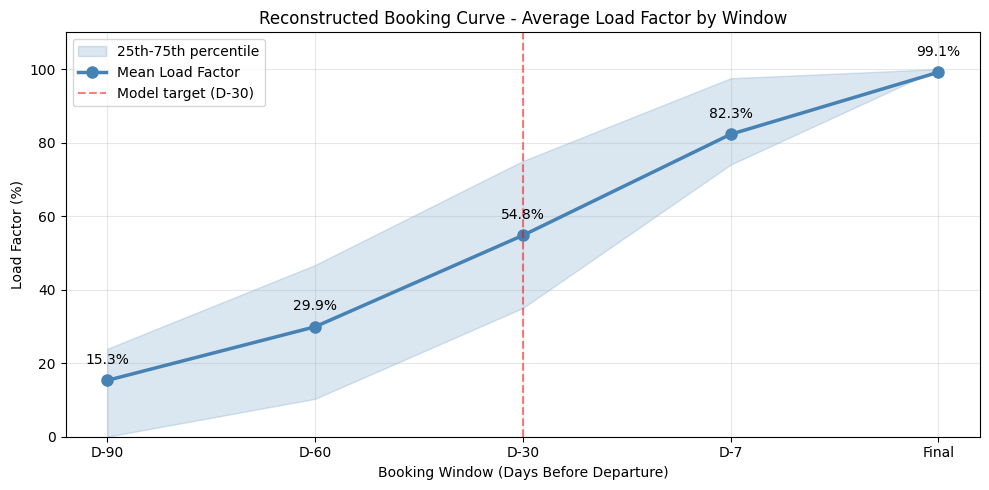

In [648]:
# Booking Curve Visualization

# Calculate mean LF at each window across all flights
windows_labels = ['D-90', 'D-60', 'D-30', 'D-7', 'Final']
mean_lf = [
    df_curves['LF_D90'].mean(),
    df_curves['LF_D60'].mean(),
    df_curves['LF_D30'].mean(),
    df_curves['LF_D7'].mean(),
    df_curves['LoadFactor'].mean()
]

# Also show 25th and 75th percentile as shaded area
p25 = [
    df_curves['LF_D90'].quantile(0.25),
    df_curves['LF_D60'].quantile(0.25),
    df_curves['LF_D30'].quantile(0.25),
    df_curves['LF_D7'].quantile(0.25),
    df_curves['LoadFactor'].quantile(0.25)
]

p75 = [
    df_curves['LF_D90'].quantile(0.75),
    df_curves['LF_D60'].quantile(0.75),
    df_curves['LF_D30'].quantile(0.75),
    df_curves['LF_D7'].quantile(0.75),
    df_curves['LoadFactor'].quantile(0.75)
]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded area = 25th to 75th percentile
ax.fill_between(windows_labels, p25, p75,
                alpha=0.2, color='steelblue',
                label='25th-75th percentile')

# Mean line
ax.plot(windows_labels, mean_lf,
        color='steelblue', linewidth=2.5,
        marker='o', markersize=8,
        label='Mean Load Factor')

ax.axvline(x=2, color='red', linestyle='--',
           alpha=0.5, linewidth=1.5,
           label='Model target (D-30)')

# Add value labels
for i, (label, val) in enumerate(zip(windows_labels, mean_lf)):
    ax.annotate(f'{val:.1f}%',
                xy=(i, val),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('Reconstructed Booking Curve - Average Load Factor by Window')
ax.set_xlabel('Booking Window (Days Before Departure)')
ax.set_ylabel('Load Factor (%)')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#7. Feature Engineering

This section constructs all features used for load factor prediction.
Feature engineering is performed in two phases:

**Phase 1: Feature Construction (external+internal)**
All features are built before the chronological train-test split.
No statistical parameters are estimated from the data.

**Phase 2: Feature Selection (post-split)**
After the chronological split, selection is applied on training data only.
This step identifies which features carry genuine predictive signal.

##7.1 Phase 1: Feature Construction (external+internal)

### Internal Features

FG-1: Product Metadata

FG-2: Booking Dynamics

---


### External Demand Signals
FG-3: Calendar & Seasonality  

FG-4:  Exchange rate USD/KZT

FG-5:  Google Trends

FG-6:  News signals



##Internal Features
###FG-1: Product Metadata

In [649]:
# Group rare airlines into 'Other'
main_airlines = ['SCAT', 'Air Astana', 'VietJet Air', 'Qanot Sharq']
df_curves['AirlineName'] = df_curves['AirlineName'].apply(
    lambda x: x if x in main_airlines else 'Other'
)

print(df_flights['AirlineName'].value_counts())

AirlineName
SCAT                           1797
Air Astana                     1164
VietJet Air                     722
Qanot Sharq                     301
Selfie Travel ТОО                23
Pegas Kazakhstan                  3
Touroperator KOMPAS               2
Selfie tour                       1
Crystal Bay Kazakhstan            1
ANEX Tourism Worldwide DMCC       1
Name: count, dtype: int64


In [650]:
# Group rare departure cities into 'Other'
df_curves['CityFrom'] = df_curves['CityFrom'].apply(
    lambda x: x if x in ['Almaty', 'Astana'] else 'Other'
)

In [651]:
print(df_curves['CityFrom'].value_counts())
print(df_curves['CityTo'].value_counts())

CityFrom
Almaty    826
Astana    540
Other      54
Name: count, dtype: int64
CityTo
Phu Quoc    681
Cam Ranh    587
Da Nang     152
Name: count, dtype: int64


In [652]:
# For each window, calculate: window_date - first_sale_date = days on sale

df_curves['first_reserve_utc'] = pd.to_datetime(df_curves['first_reserve_utc'])

for w_name, w_days in {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}.items():

    # When is this window? (departure - 90 days)
    window_date = df_curves['BlockDate'] - pd.Timedelta(days=w_days)

    # How many days was the flight on sale by this window
    df_curves[f'days_in_sale_{w_name}'] = (
        window_date - df_curves['first_reserve_utc']
    ).dt.days.clip(lower=0)  # if flight not yet open = 0, not negative

In [653]:
print(df_curves[['days_in_sale_D90', 'days_in_sale_D60',
                  'days_in_sale_D30', 'days_in_sale_D7']].describe().round(1))

       days_in_sale_D90  days_in_sale_D60  days_in_sale_D30  days_in_sale_D7
count            1420.0            1420.0            1420.0           1420.0
mean               71.9              99.7             129.0            152.0
std                53.3              56.6              57.8             58.0
min                 0.0               0.0               0.0              0.0
25%                28.0              58.0              88.0            111.0
50%                65.5              95.5             125.5            148.5
75%               112.0             142.0             172.0            195.0
max               206.0             236.0             266.0            289.0


In [654]:
# Per-window hotel & product aggregates
# This ensures we only use bookings visible at prediction time

windows_hotel = {'D90': 90, 'D60': 60, 'D30': 30}

for window_name, days in windows_hotel.items():

    # Keep only bookings visible at this window
    cutoff_per_booking = df_joined_all['BlockDate'] - pd.Timedelta(days=days)
    is_visible = df_joined_all['ClaimCreatedDT_UTC'] <= cutoff_per_booking
    df_visible = df_joined_all[is_visible].copy()

    # Aggregate from visible bookings only
    window_agg = df_visible.groupby(['FreightID_Fwd', 'BlockDate']).agg(
        avg_hotel_cost   = ('HotelCost',      'mean'),
        avg_stars        = ('HotelStars_num', 'mean'),
        avg_nights       = ('TourNights',     'mean'),
        avg_pax          = ('PaxSeats',       'mean'),
        avg_flight_cost  = ('FlightCost_Fwd', 'mean'),
        unique_hotels    = ('HotelName',      'nunique'),
        pct_phu_quoc     = ('HotelRegion',    lambda x: (x == 'Phu Quoc').mean()),
        pct_nha_trang    = ('HotelRegion',    lambda x: (x == 'Nha Trang').mean()),
        pct_da_nang      = ('HotelRegion',    lambda x: (x == 'Da Nang').mean()),
        bookings_visible = ('ClaimID',        'count'),
    ).reset_index()

    # Add window suffix to all new columns
    rename_cols = {
        col: f'{col}_{window_name}'
        for col in window_agg.columns
        if col not in ['FreightID_Fwd', 'BlockDate']
    }
    window_agg = window_agg.rename(columns=rename_cols)

    # Merge into df_curves — keep all 1,420 flights
    df_curves = df_curves.merge(
        window_agg,
        on=['FreightID_Fwd', 'BlockDate'],
        how='left'
    )

    print(f"{window_name}: {len(df_visible):,} visible bookings | "
          f"flights with 0 bookings: {df_curves[f'bookings_visible_{window_name}'].isnull().sum()}")

# Sanity check: values should differ slightly across windows
print("\nMean avg_hotel_cost by window (should differ):")
for w in ['D90', 'D60', 'D30']:
    print(f"  {w}: ${df_curves[f'avg_hotel_cost_{w}'].mean():.1f}")

D90: 5,416 visible bookings | flights with 0 bookings: 469
D60: 10,449 visible bookings | flights with 0 bookings: 208
D30: 19,649 visible bookings | flights with 0 bookings: 43

Mean avg_hotel_cost by window (should differ):
  D90: $1358.7
  D60: $1285.5
  D30: $1274.7


In [655]:
# Fill NaN = 0 for flights with no visible bookings at a window
# Prevent errors for simple models such as Linear Regression & Random Forest
# XGBoost and LightGBM handle NaN natively, but sklearn models do not.

hotel_cols = [c for c in df_curves.columns if any(
    c.startswith(p) for p in [
        'avg_hotel_cost', 'avg_stars', 'avg_nights',
        'avg_pax', 'avg_flight_cost', 'unique_hotels',
        'pct_phu_quoc', 'pct_nha_trang', 'pct_da_nang',
        'bookings_visible'
    ]
)]

df_curves[hotel_cols] = df_curves[hotel_cols].fillna(0)

# Verify no NaNs remain
print(f"NaN values remaining: {df_curves[hotel_cols].isnull().sum().sum()}")
print(f"df_curves shape: {df_curves.shape}")

NaN values remaining: 0
df_curves shape: (1420, 55)


### FG-1 Summary: Product Metadata

**1. Flight characteristics** already present in df_curves after aggregation in Section 6.

No new calculation needed, only categorical grouping applied here.

| Feature | Description | Action |
|---|---|---|
| AirlineName | SCAT, Air Astana, VietJet Air, Qanot Sharq, Other | Grouped rare values to Other |
| CityFrom | Departure city (Almaty, Astana, Other) | Grouped rare values to Other |
| CityTo | Destination (Phu Quoc, Cam Ranh, Da Nang) | Already in df_curves |
| Seats_gross | Aircraft capacity | Already in df_curves |
| HasStopSale | Stop sale flag (0/1) | Already in df_curves |


**2. Sales window features** calculated here from first_reserve_utc.

| Feature | Description |
|---|---|
| days_in_sale_D90 | How many days on sale by D-90 |
| days_in_sale_D60 | How many days on sale by D-60 |
| days_in_sale_D30 | How many days on sale by D-30 |

These features provide the model with context about how long demand has had to accumulate.

**3. Hotel & Product features** calculated per window from visible bookings only.
Aggregated from bookings visible at each prediction window (D-90, D-60, D-30).
Using all bookings regardless of window would introduce data leakage.

| Feature | Description |
|---|---|
| avg_hotel_cost_DXX | Average hotel cost of bookings visible at window |
| avg_stars_DXX | Average hotel star rating of visible bookings |
| avg_nights_DXX | Average tour duration (nights) of visible bookings |
| avg_pax_DXX | Average group size of visible bookings |
| avg_flight_cost_DXX | Average forward flight cost of visible bookings |
| unique_hotels_DXX | Number of distinct hotels in visible bookings |
| pct_phu_quoc_DXX | Share of visible bookings going to Phu Quoc |
| pct_nha_trang_DXX | Share of visible bookings going to Nha Trang |
| pct_da_nang_DXX | Share of visible bookings going to Da Nang |
| bookings_visible_DXX | Count of bookings visible at this window |

Where DXX = D90, D60, or D30. Total: 30 columns (10 features × 3 windows).

### FG-2: Booking Dynamics

In [656]:
# How fast are bookings coming in between windows?
# velocity = change in LF between two windows

df_curves['velocity_D90_D60'] = df_curves['LF_D60'] - df_curves['LF_D90']
df_curves['velocity_D60_D30'] = df_curves['LF_D30'] - df_curves['LF_D60']
df_curves['velocity_D30_D7']  = df_curves['LF_D7']  - df_curves['LF_D30']

# Is demand speeding up or slowing down?
# Acceleration: is demand speeding up or slowing down between known windows?
# Uses only D-90, D-60, D-30 - no leakage
df_curves['acceleration'] = df_curves['velocity_D60_D30'] - df_curves['velocity_D90_D60']


print(df_curves[['velocity_D90_D60', 'velocity_D60_D30',
                  'velocity_D30_D7', 'acceleration']].describe().round(2))

       velocity_D90_D60  velocity_D60_D30  velocity_D30_D7  acceleration
count           1420.00           1420.00          1420.00       1420.00
mean              14.58             24.86            27.50         10.28
std               15.36             18.02            19.62         24.86
min                0.00              0.00             0.00       -100.00
25%                2.10             12.30            12.27         -2.93
50%               10.35             21.95            25.40         10.00
75%               20.72             35.00            40.00         23.92
max              100.00            100.00           100.00        100.00


### FG-2 Summary: Booking Dynamics

Four features describing how fast demand accumulates between windows.

| Feature | Description | Status |
|---|---|---|
| velocity_D90_D60 | LF change between D-90 and D-60 | Used in model |
| velocity_D60_D30 | LF change between D-60 and D-30 | Used in model |
| velocity_D30_D7 | LF change between D-30 and D-7 | Will be excluded, unavailable at prediction time |
| acceleration | Change in velocity (D60_D30 minus D90_D60) | Used in model |

Mean velocity increases from 14.6 at D90 -> D60 to 27.5 at D30 -> D7,
confirming the late booking pattern identified in EDA.

Acceleration ranges from -100 to +100. A positive value means bookings are coming in faster closer to departure, a negative value means demand slowed down between early and late windows.

##External Features
###FG-3: Calendar & Seasonality  

In [657]:
# Load calendar dictionary
dict_cal = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dict_calendar.csv'
)
dict_cal['cal_date'] = pd.to_datetime(dict_cal['cal_date'])

In [658]:
dict_cal.head()

,cal_date,is_holiday,is_weekend,is_school_holiday,source,loaded_at,is_summer_holiday
0,2024-01-01,1,0,1,Nager.Date API,2026-04-01 16:37:59,0
1,2024-01-02,1,0,1,Nager.Date API,2026-04-01 16:37:59,0
2,2024-01-03,0,0,1,Nager.Date API,2026-04-01 16:37:59,0
3,2024-01-04,0,0,1,Nager.Date API,2026-04-01 16:37:59,0
4,2024-01-05,0,0,1,Nager.Date API,2026-04-01 16:37:59,0


In [659]:
# Basic departure date features
df_curves['departure_month']   = df_curves['BlockDate'].dt.month
df_curves['departure_quarter'] = df_curves['BlockDate'].dt.quarter
df_curves['departure_dow']     = df_curves['BlockDate'].dt.dayofweek  # 0=Monday
df_curves['departure_week']    = df_curves['BlockDate'].dt.isocalendar().week.astype(int)

In [660]:
# Join holiday and school vacation flags
df_curves = df_curves.merge(
    dict_cal[['cal_date', 'is_holiday', 'is_weekend',
              'is_school_holiday', 'is_summer_holiday']],
    left_on='BlockDate',
    right_on='cal_date',
    how='left'
).drop(columns=['cal_date'])

In [661]:
print("Shape:", df_curves.shape)
print(df_curves[['departure_month', 'departure_quarter', 'departure_dow',
                  'departure_week', 'is_holiday', 'is_weekend',
                  'is_school_holiday', 'is_summer_holiday']].isnull().sum())

Shape: (1420, 67)
departure_month      0
departure_quarter    0
departure_dow        0
departure_week       0
is_holiday           0
is_weekend           0
is_school_holiday    0
is_summer_holiday    0
dtype: int64


### FG-3 Summary: Calendar & Seasonality

Eight calendar features were added to df_curves based on the departure date (BlockDate).

| Feature | Description | Source |
|---|---|---|
| departure_month | Month of departure (1-12) | BlockDate |
| departure_quarter | Quarter of departure (1-4) | BlockDate |
| departure_dow | Day of week (0=Monday) | BlockDate |
| departure_week | Week of year (1-52) | BlockDate |
| is_holiday | Public holiday flag (0/1) | dict_calendar.csv |
| is_weekend | Weekend flag (0/1) | dict_calendar.csv |
| is_school_holiday | School vacation flag (0/1) | dict_calendar.csv |
| is_summer_holiday | Summer vacation flag (0/1) | dict_calendar.csv |

###FG-4:  Exchange rate USD/KZT

For each flight at each window, calculate average KZT/USD rate over the 30 days before the window date

In [662]:
# Load and prepare
fx = pd.read_csv('/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dict_currency_pairs.csv')
fx['rate_date'] = pd.to_datetime(fx['rate_date'])


# Keep only KZT/USD rate
fx = fx[
    (fx['base_currency'] == 'KZT') &
    (fx['quote_currency'] == 'USD')
][['rate_date', 'rate']]

fx.head()

,rate_date,rate
0,2024-01-01,455.51
1,2024-01-02,452.88
2,2024-01-03,454.42
3,2024-01-04,451.80
4,2024-01-05,450.81


In [663]:
# For each window, compute 30-day average rate before window date
fx_daily = fx.set_index('rate_date')['rate']

for w_name, w_days in {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}.items():

    # Calculate window date for each flight
    window_dates = df_curves['BlockDate'] - pd.Timedelta(days=w_days)

    # For each window date, get 30-day average before it
    df_curves[f'fx_rate_30d_{w_name}'] = window_dates.apply(
        lambda d: fx_daily[
            (fx_daily.index >= d - pd.Timedelta(days=30)) &
            (fx_daily.index <= d)
        ].mean()
    )

# NOTE: fx_rate_30d_D7 is computed here for completeness
# but excluded from model features, unavailable at prediction time (D-30 target)

print(df_curves[['fx_rate_30d_D90', 'fx_rate_30d_D60',
                  'fx_rate_30d_D30', 'fx_rate_30d_D7']].describe().round(2))

       fx_rate_30d_D90  fx_rate_30d_D60  fx_rate_30d_D30  fx_rate_30d_D7
count          1420.00          1420.00          1420.00         1420.00
mean            509.30           511.02           512.41          513.22
std              20.91            18.12            15.67           14.75
min             455.45           472.03           475.89          477.42
25%             495.59           499.68           505.38          505.01
50%             510.88           512.11           511.91          511.43
75%             524.63           522.58           521.89          522.31
max             540.43           540.43           540.43          540.43


### FG-4 Summary: Exchange Rate USD/KZT

One feature per booking window — 30-day average KZT/USD rate
before the window date.

| Feature | Description |
|---|---|
| fx_rate_30d_D90 | Average KZT/USD rate in 30 days before D-90 |
| fx_rate_30d_D60 | Average KZT/USD rate in 30 days before D-60 |
| fx_rate_30d_D30 | Average KZT/USD rate in 30 days before D-30 |

Vietnam tours are priced in USD but paid in KZT.
A weaker tenge (higher rate) increases the effective cost of the tour,
which may suppress demand.

The 30-day average is used instead of a
single day value to capture the general exchange rate trend that
customers experience when making booking decisions.

Mean rate across the dataset: roughly 510 KZT/USD, ranging from 455 to 540.

Source: dict_currency_pairs.csv (Jan 2024 - Mar 2026).

###FG-5: Google Trends

Search interest from Kazakhstan for Vietnam-related queries. Measured 30 days before each window date (AS-OF join)

In [664]:
# Load
gt = pd.read_csv('/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/ext_google_trends.csv')
gt['trend_date'] = pd.to_datetime(gt['trend_date'])

In [665]:
gt.head()

,trend_date,keyword,geo,interest,category,source,loaded_at
0,2024-01-01,vietnam almaty,KZ,0,purchase_intent,Google Trends,2026-04-02 12:35:48
1,2024-01-01,vietnam april,KZ,0,seasonal_intent,Google Trends,2026-04-02 12:54:55
2,2024-01-01,vietnam march,KZ,0,seasonal_intent,Google Trends,2026-04-02 12:53:23
3,2024-01-02,vietnam almaty,KZ,0,purchase_intent,Google Trends,2026-04-02 12:35:48
4,2024-01-02,vietnam april,KZ,0,seasonal_intent,Google Trends,2026-04-02 12:54:55


In [666]:
# Separate by category daily average across all keywords in each category
gt_purchase = gt[gt['category'] == 'purchase_intent'].groupby('trend_date')['interest'].mean()
gt_seasonal = gt[gt['category'] == 'seasonal_intent'].groupby('trend_date')['interest'].mean()

In [667]:
# For each window compute 30-day average before window date
for w_name, w_days in {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}.items():
    window_dates = df_curves['BlockDate'] - pd.Timedelta(days=w_days)

    df_curves[f'gt_purchase_30d_{w_name}'] = window_dates.apply(
        lambda d: gt_purchase[
            (gt_purchase.index >= d - pd.Timedelta(days=30)) &
            (gt_purchase.index <= d)
        ].mean()
    )

    df_curves[f'gt_seasonal_30d_{w_name}'] = window_dates.apply(
        lambda d: gt_seasonal[
            (gt_seasonal.index >= d - pd.Timedelta(days=30)) &
            (gt_seasonal.index <= d)
        ].mean()
    )

In [668]:
print(df_curves[['gt_purchase_30d_D90', 'gt_purchase_30d_D7',
                  'gt_seasonal_30d_D90', 'gt_seasonal_30d_D7']].describe().round(2))
print('\nNull check:')
print(df_curves[['gt_purchase_30d_D90', 'gt_purchase_30d_D7',
                  'gt_seasonal_30d_D90', 'gt_seasonal_30d_D7']].isnull().sum())

       gt_purchase_30d_D90  gt_purchase_30d_D7  gt_seasonal_30d_D90  \
count              1420.00             1420.00              1420.00   
mean                  1.18                1.42                 0.94   
std                   1.58                1.65                 1.13   
min                   0.00                0.00                 0.00   
25%                   0.00                0.00                 0.00   
50%                   0.00                1.08                 0.00   
75%                   2.15                2.15                 1.61   
max                   5.81                5.81                 3.23   

       gt_seasonal_30d_D7  
count             1420.00  
mean                 0.95  
std                  1.15  
min                  0.00  
25%                  0.00  
50%                  0.00  
75%                  1.61  
max                  3.23  

Null check:
gt_purchase_30d_D90    0
gt_purchase_30d_D7     0
gt_seasonal_30d_D90    0
gt_seasonal_30d_D7  

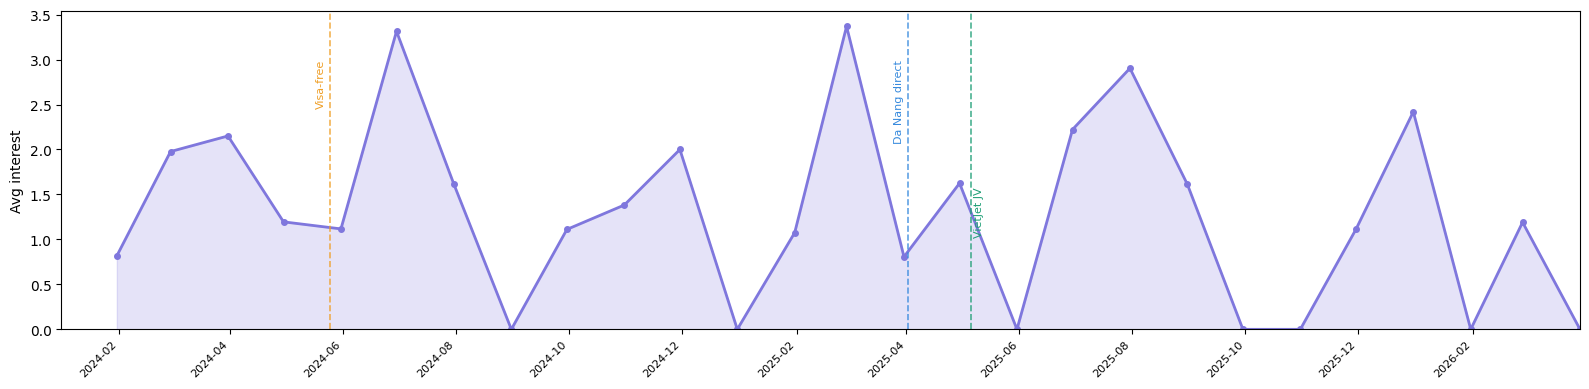

In [669]:
gt_daily = gt.groupby('trend_date')['interest'].mean()

fig, ax1 = plt.subplots(figsize=(16, 4))

gt_monthly = gt_daily.resample('ME').mean()
ax1.plot(gt_monthly.index, gt_monthly.values,
         color='#7F77DD', linewidth=2, marker='o', markersize=4)
ax1.fill_between(gt_monthly.index, gt_monthly.values,
                 alpha=0.2, color='#7F77DD')
ax1.set_ylabel('Avg interest', fontsize=10)
ax1.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2026-03-31'))
ax1.set_ylim(0)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right', fontsize=8)

events = {
    '2024-05-25': ('Visa-free',      '#EF9F27', 0.85, 'right'),
    '2025-04-02': ('Da Nang direct', '#378ADD',  0.85, 'right'),
    '2025-05-06': ('VietJet JV',     '#1D9E75',  0.45, 'left'),
}
for date_str, (label, color, ypos, ha) in events.items():
    d = pd.Timestamp(date_str)
    offset = pd.Timedelta(days=-2) if ha == 'right' else pd.Timedelta(days=2)
    ax1.axvline(d, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax1.text(d + offset, ax1.get_ylim()[1] * ypos, label,
             fontsize=8, color=color, rotation=90, va='top', ha=ha)

plt.tight_layout()
plt.show()

### FG-5 Summary: Google Trends

Two features per booking window — 30-day average search interest
from Kazakhstan (geo=KZ) before the window date.

| Feature | Description |
|---|---|
| gt_purchase_30d_D90 | Avg purchase intent search interest 30 days before D-90 |
| gt_purchase_30d_D60 | Avg purchase intent search interest 30 days before D-60 |
| gt_purchase_30d_D30 | Avg purchase intent search interest 30 days before D-30 |
| gt_seasonal_30d_D90 | Avg seasonal intent search interest 30 days before D-90 |
| gt_seasonal_30d_D60 | Avg seasonal intent search interest 30 days before D-60 |
| gt_seasonal_30d_D30 | Avg seasonal intent search interest 30 days before D-30 |

purchase_intent captures active booking searches "vietnam tours",
"vietnam almaty", "last minute tours vietnam" (5 keywords).
seasonal_intent captures planning searches by month "vietnam march",
"vietnam april" etc. (13 keywords).

Values range from 0 to 6 on a 0-100 Google Trends scale, indicating
low absolute search volume for Kazakhstan-Vietnam queries.

If feature importance scores confirm low predictive value, this may
suggest that B2B charter demand in this market is driven by agency
push rather than consumer search behaviour.

Source: ext_google_trends_en.csv (Google Trends, geo=KZ, Jan 2024 – Mar 2026).

###FG-6:  News signals

In [670]:
news = pd.read_csv('/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/ext_news.csv')
news['article_date'] = pd.to_datetime(news['article_date'])
print(news.shape)
print(news.columns.tolist())
print(news['category'].value_counts())

(566, 10)
['article_date', 'title', 'url', 'source', 'theme_group', 'relevance_score', 'category', 'sentiment_score', 'llm_reason', 'inserted_at']
category
noise       365
aviation     85
demand       80
disaster     29
visa          7
Name: count, dtype: int64


In [671]:
news.head()

,article_date,title,url,source,theme_group,relevance_score,category,sentiment_score,llm_reason,inserted_at
0,2025-12-29,Kazakh Citizens Choose Beach Getaways and Dome...,https://astanatimes.com/2025/12/kazakh-citizen...,astanatimes.com,tourism,3,demand,0.1,Article discusses general Kazakh outbound trav...,2026-04-17 11:05:31
1,2025-12-23,Куда и за сколько летят отдыхать казахстанцы н...,https://forbes.kz/articles/kuda-i-za-skolko-le...,forbes.kz,tourism,5,demand,0.0,Article discusses where Kazakh tourists travel...,2026-04-08 16:02:17
2,2025-12-16,Breakfast @ Tuoi Tre News - December 16,https://news.tuoitre.vn/breakfast-tuoi-tre-new...,news.tuoitre.vn,tourism,0,noise,0.0,The article is a general Vietnamese news round...,2026-04-08 16:02:17
3,2025-12-19,Da Nang proposes $10bn investment in Chu Lai a...,https://news.tuoitre.vn/da-nang-proposes-10bn-...,news.tuoitre.vn,tourism,2,aviation,0.0,The article discusses Vietnam airport infrastr...,2026-04-08 16:02:17
4,2025-12-12,Vietnam faces challenge turning tourist number...,https://news.tuoitre.vn/vietnam-faces-challeng...,news.tuoitre.vn,tourism,5,demand,0.0,The article discusses overall Vietnam tourism ...,2026-04-08 16:02:17


In [672]:
# Remove noise
news_signal = news[
    (news['category'] != 'noise') &
    (news['relevance_score'] >= 5)
].copy()

In [673]:
# Structural dummies
# Permanent market changes — 0 before event date, 1 after

STRUCTURAL_EVENTS = {
    'post_visa_free':      '2024-05-25',  # KZ-VN visa-free agreement
    'post_da_nang_direct': '2025-04-02',  # Da Nang direct flights launched
    'post_vietjet_jv':     '2025-05-06',  # VietJet + QazaqAir joint venture
}

for feat_name, event_date in STRUCTURAL_EVENTS.items():
    cutoff = pd.Timestamp(event_date)
    df_curves[feat_name] = (df_curves['BlockDate'] >= cutoff).astype(int)

In [674]:
# Rolling sentiment
# Disaster and demand sentiment 30 days before each window date

disaster = news_signal[news_signal['category'] == 'disaster'].set_index('article_date')['sentiment_score']
demand   = news_signal[news_signal['category'] == 'demand'].set_index('article_date')['sentiment_score']

for w_name, w_days in {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}.items():
    window_dates = df_curves['BlockDate'] - pd.Timedelta(days=w_days)

    df_curves[f'disaster_sentiment_30d_{w_name}'] = window_dates.apply(
        lambda d: disaster[
            (disaster.index >= d - pd.Timedelta(days=30)) &
            (disaster.index <= d)
        ].mean() if len(disaster[
            (disaster.index >= d - pd.Timedelta(days=30)) &
            (disaster.index <= d)
        ]) > 0 else 0.0
    )

    df_curves[f'demand_sentiment_30d_{w_name}'] = window_dates.apply(
        lambda d: demand[
            (demand.index >= d - pd.Timedelta(days=30)) &
            (demand.index <= d)
        ].mean() if len(demand[
            (demand.index >= d - pd.Timedelta(days=30)) &
            (demand.index <= d)
        ]) > 0 else 0.0
    )

In [675]:
print("Structural dummies:")
print(df_curves[['post_visa_free',
                  'post_da_nang_direct',
                  'post_vietjet_jv']].value_counts())
print("\nRolling sentiment sample:")
print(df_curves[['disaster_sentiment_30d_D90', 'disaster_sentiment_30d_D7',
                  'demand_sentiment_30d_D90',   'demand_sentiment_30d_D7']].describe().round(3))

Structural dummies:
post_visa_free  post_da_nang_direct  post_vietjet_jv
1               1                    1                  905
                0                    0                  418
                1                    0                   97
Name: count, dtype: int64

Rolling sentiment sample:
       disaster_sentiment_30d_D90  disaster_sentiment_30d_D7  \
count                    1420.000                   1420.000   
mean                       -0.143                     -0.120   
std                         0.255                      0.223   
min                        -0.800                     -0.700   
25%                        -0.300                      0.000   
50%                         0.000                      0.000   
75%                         0.000                      0.000   
max                         0.000                      0.000   

       demand_sentiment_30d_D90  demand_sentiment_30d_D7  
count                  1420.000                 1420.000  

In [676]:
# Check which FG-6 columns were actually created
fg6_cols = [c for c in df_curves.columns if 'sentiment' in c or 'post_' in c]
print("FG-6 columns created:", fg6_cols)
print("\ndf_curves shape:", df_curves.shape)

FG-6 columns created: ['post_visa_free', 'post_da_nang_direct', 'post_vietjet_jv', 'disaster_sentiment_30d_D90', 'demand_sentiment_30d_D90', 'disaster_sentiment_30d_D60', 'demand_sentiment_30d_D60', 'disaster_sentiment_30d_D30', 'demand_sentiment_30d_D30', 'disaster_sentiment_30d_D7', 'demand_sentiment_30d_D7']

df_curves shape: (1420, 90)


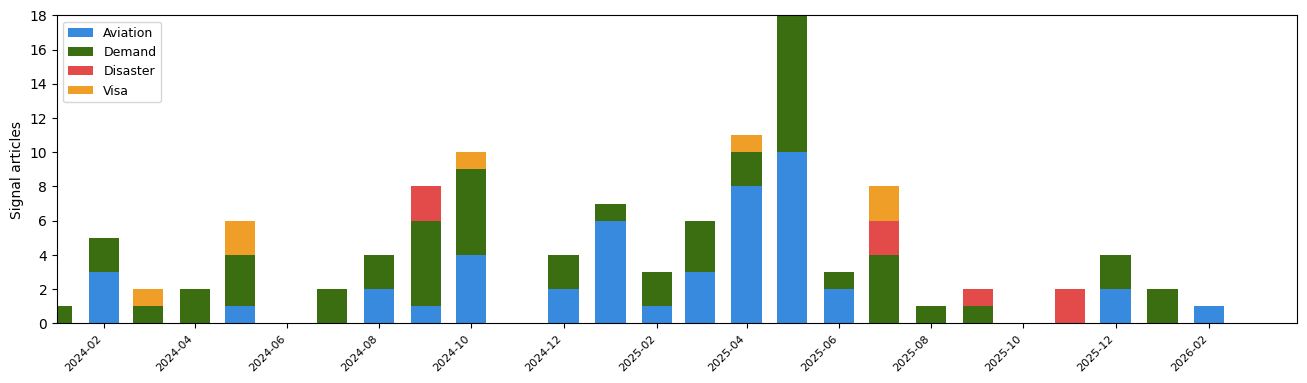

In [677]:
# News articles plot

fig, ax2 = plt.subplots(figsize=(16, 4))

news_signal = news[
    (news['relevance_score'] >= 5) &
    (news['category'] != 'noise')
].copy()
news_signal['month'] = news_signal['article_date'].dt.to_period('M').dt.to_timestamp()
monthly_news = news_signal.groupby(['month', 'category']).size().unstack(fill_value=0)

colors = {'aviation': '#378ADD', 'demand': '#3B6D11',
          'disaster': '#E24B4A', 'visa':   '#EF9F27'}
bottom = pd.Series(0, index=monthly_news.index)
for cat in ['aviation', 'demand', 'disaster', 'visa']:
    if cat in monthly_news.columns:
        ax2.bar(monthly_news.index, monthly_news[cat],
                bottom=bottom, label=cat.capitalize(),
                color=colors[cat], width=20)
        bottom += monthly_news[cat]

ax2.set_ylabel('Signal articles', fontsize=10)
ax2.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2026-03-31'))
ax2.legend(fontsize=9, loc='upper left')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.show()

### FG-6 Summary: News Signals

Features constructed from 566 news articles
collected across Kazakh and Vietnamese media sources.

**Structural dummies**
Permanent market changes encoded as step functions — 0 before
the event date, 1 after.

| Feature | Event | Date |
|---|---|---|
| post_visa_free | KZ–VN visa-free agreement | 2024-05-25 |
| post_da_nang_direct | Da Nang direct flights launched | 2025-04-02 |
| post_vietjet_jv | VietJet + QazaqAir joint venture | 2025-05-06 |

**Rolling sentiment**
Average sentiment score of disaster and demand articles
in the 30 days before each window date.

| Feature | Description |
|---|---|
| disaster_sentiment_30d_D90/60/30 | Avg sentiment of disaster articles (typhoons, floods, safety incidents) |
| demand_sentiment_30d_D90/60/30 | Avg sentiment of demand articles (tourism growth, destination popularity) |

After filtering noise and low-relevance articles, 112 signal
articles were retained across four categories: aviation,
demand, disaster, and visa.

Disaster sentiment mean = -0.14, confirming negative tone
of safety-related events.

Demand sentiment mean = +0.31,
reflecting consistently positive media coverage of
Vietnam tourism from Kazakhstan.

Source: ext_news.csv (LLM-scored, Jan 2024 – Mar 2026).

In [678]:
# Null check
nulls = df_curves.isnull().sum()
print("Null check:")
print(nulls[nulls > 0] if nulls.any() else "No nulls")

Null check:
No nulls


In [679]:
# Save
df_curves.to_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/df_curves_features.csv',
    index=False
)
print("\nSaved")
print(f"Shape: {df_curves.shape}")


Saved
Shape: (1420, 90)


#Chronological Splitting and Feature Selection

###Chronological Splitting
This ensures the model learns from past flights and is tested on future flights it has never seen

In [680]:
# Define the split point
split_date = pd.Timestamp('2025-11-01')

# Split into train and test
train = df_curves[df_curves['BlockDate'] < split_date].copy()
test  = df_curves[df_curves['BlockDate'] >= split_date].copy()

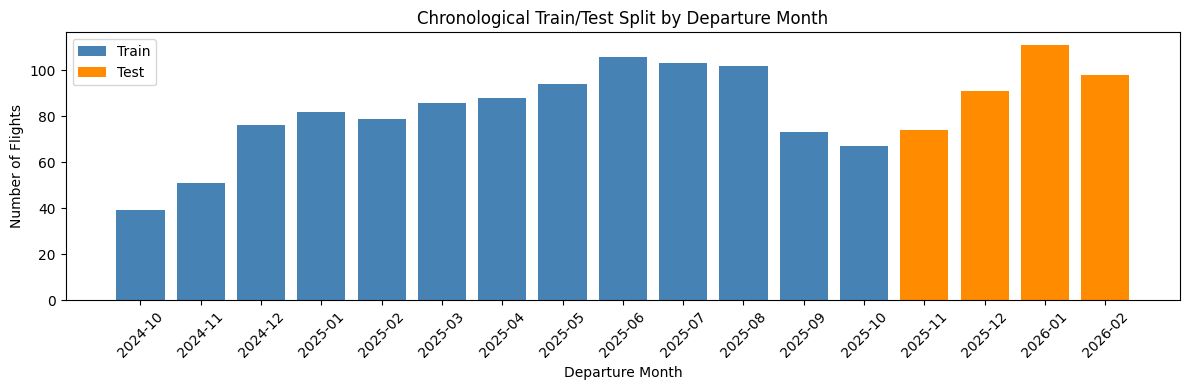

In [681]:
# Visualise the chronological split
train_monthly = train.groupby(
    train['BlockDate'].dt.to_period('M')
).size()

test_monthly = test.groupby(
    test['BlockDate'].dt.to_period('M')
).size()

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

# Train bars — blue
ax.bar(train_monthly.index.astype(str),
       train_monthly.values,
       color='steelblue', label='Train')

# Test bars — orange
ax.bar(test_monthly.index.astype(str),
       test_monthly.values,
       color='darkorange', label='Test')

ax.set_title('Chronological Train/Test Split by Departure Month')
ax.set_xlabel('Departure Month')
ax.set_ylabel('Number of Flights')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [682]:
print(f"Total flights:  {len(df_curves):,}")
print(f"\nTrain: {len(train):,} flights ({len(train)/len(df_curves)*100:.1f}%)")
print(f"  Period: {train['BlockDate'].min().date()} — {train['BlockDate'].max().date()}")
print(f"  LF_D30: mean={train['LF_D30'].mean():.1f}%, std={train['LF_D30'].std():.1f}%")

print(f"\nTest:  {len(test):,} flights ({len(test)/len(df_curves)*100:.1f}%)")
print(f"  Period: {test['BlockDate'].min().date()} — {test['BlockDate'].max().date()}")
print(f"  LF_D30: mean={test['LF_D30'].mean():.1f}%, std={test['LF_D30'].std():.1f}%")

Total flights:  1,420

Train: 1,046 flights (73.7%)
  Period: 2024-10-01 — 2025-10-31
  LF_D30: mean=52.3%, std=27.3%

Test:  374 flights (26.3%)
  Period: 2025-11-01 — 2026-02-28
  LF_D30: mean=61.6%, std=21.7%


In [683]:
# std of final LoadFactor across all flights
print(f"LoadFactor std: {df_curves['LoadFactor'].std():.3f}")
print(f"LoadFactor mean: {df_curves['LoadFactor'].mean():.1f}%")
print(f"LoadFactor value counts (binned):")
print((df_curves['LoadFactor'] >= 100).value_counts())

LoadFactor std: 3.264
LoadFactor mean: 99.1%
LoadFactor value counts (binned):
LoadFactor
True     1168
False     252
Name: count, dtype: int64


# Chronological Split Summary

Data is split by departure date (BlockDate), not randomly. This ensures the model is always trained on past flights and evaluated on future flights.

Split point: November 1, 2025
Train: Oct 2024 – Oct 2025 = 1,046 flights (73.7%), LF_D30 mean=52.3%, std=27.3%
Test:  Nov 2025 – Feb 2026 =   374 flights (26.3%), LF_D30 mean=61.6%, std=21.7%


Test covers the winter high season (Nov–Feb) which is the most commercially important period for Kazakhstan–Vietnam charter routes.

Feature selection will be applied on TRAIN only to prevent any test-set information from influencing which features are retained.

#Feature Selection
Feature selection is performed on the training set only, ensuring that no information from the test set influences which features are retained.

Step 1: Collinearity filter — Remove duplicate features

Step 2: Mutual Information — Remove uninformative features

Step 3: Tree Importance — Confirm which features matter at each horizon

OUTPUT: Final feature set

In [684]:
# Define feature columns for model training
# Explicitly exclude: target, leakage features, IDs, and D-7 window features

EXCLUDE = [
    # Target and near-target
    'LF_D30', 'LF_D7', 'LoadFactor','Sold_gross', 'total_bookings',

    # Not useful
    'FreightID_Fwd', 'BlockDate', 'is_zero_lf',

    # Leakage: require information unavailable at prediction time
    'velocity_D30_D7','cum_seats_D7', 'days_in_sale_D7',

    # D-7 external features (unavailable at D-30 prediction time)
    'fx_rate_30d_D7',
    'gt_purchase_30d_D7', 'gt_seasonal_30d_D7',
    'disaster_sentiment_30d_D7', 'demand_sentiment_30d_D7',

     # Booking counts per window — redundant with cum_seats_DXX
    'bookings_visible_D90', 'bookings_visible_D60', 'bookings_visible_D30',
]

feature_cols = [
    c for c in train.select_dtypes(include='number').columns
    if c not in EXCLUDE
]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 67
['cum_seats_D90', 'cum_seats_D60', 'cum_seats_D30', 'Seats_gross', 'HasStopSale', 'LF_D90', 'LF_D60', 'censored_at_D60', 'days_in_sale_D90', 'days_in_sale_D60', 'days_in_sale_D30', 'avg_hotel_cost_D90', 'avg_stars_D90', 'avg_nights_D90', 'avg_pax_D90', 'avg_flight_cost_D90', 'unique_hotels_D90', 'pct_phu_quoc_D90', 'pct_nha_trang_D90', 'pct_da_nang_D90', 'avg_hotel_cost_D60', 'avg_stars_D60', 'avg_nights_D60', 'avg_pax_D60', 'avg_flight_cost_D60', 'unique_hotels_D60', 'pct_phu_quoc_D60', 'pct_nha_trang_D60', 'pct_da_nang_D60', 'avg_hotel_cost_D30', 'avg_stars_D30', 'avg_nights_D30', 'avg_pax_D30', 'avg_flight_cost_D30', 'unique_hotels_D30', 'pct_phu_quoc_D30', 'pct_nha_trang_D30', 'pct_da_nang_D30', 'velocity_D90_D60', 'velocity_D60_D30', 'acceleration', 'departure_month', 'departure_quarter', 'departure_dow', 'departure_week', 'is_holiday', 'is_weekend', 'is_school_holiday', 'is_summer_holiday', 'fx_rate_30d_D90', 'fx_rate_30d_D60', 'fx_rate_30d_D30', 'gt_purchase_3

  ### Step 1: Collinearity

In [685]:
# Remove one feature from each pair where r > 0.90

corr_matrix = train[feature_cols].select_dtypes(include='number').corr().abs()

# Find highly correlated pairs
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            # Drop the second feature in the pair
            to_drop.add(corr_matrix.columns[j])

print(f"Features to drop due to high correlation: {len(to_drop)}")
print(to_drop)

Features to drop due to high correlation: 9
{'avg_nights_D60', 'avg_nights_D90', 'departure_quarter', 'departure_week', 'unique_hotels_D90', 'avg_pax_D90', 'pct_phu_quoc_D30', 'days_in_sale_D60', 'days_in_sale_D30'}


In [686]:
feature_cols_filtered = [f for f in feature_cols if f not in to_drop]

print(f"Features before: {len(feature_cols)}")
print(f"Features removed: {len(to_drop)}")
print(f"Features after:  {len(feature_cols_filtered)}")

Features before: 67
Features removed: 9
Features after:  58


###Step 2: Mutual Information

In [687]:
X_train = train[feature_cols_filtered].select_dtypes(include='number').fillna(0)
y_train = train['LF_D30']  # D-30 as representative target, because Features that matter at D-30 generally matter at other windows too.

In [688]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=42) # random_state=42 makes same result every run

In [689]:
# Create a neat table: feature name + its MI score
# Sort from most useful to least useful
mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

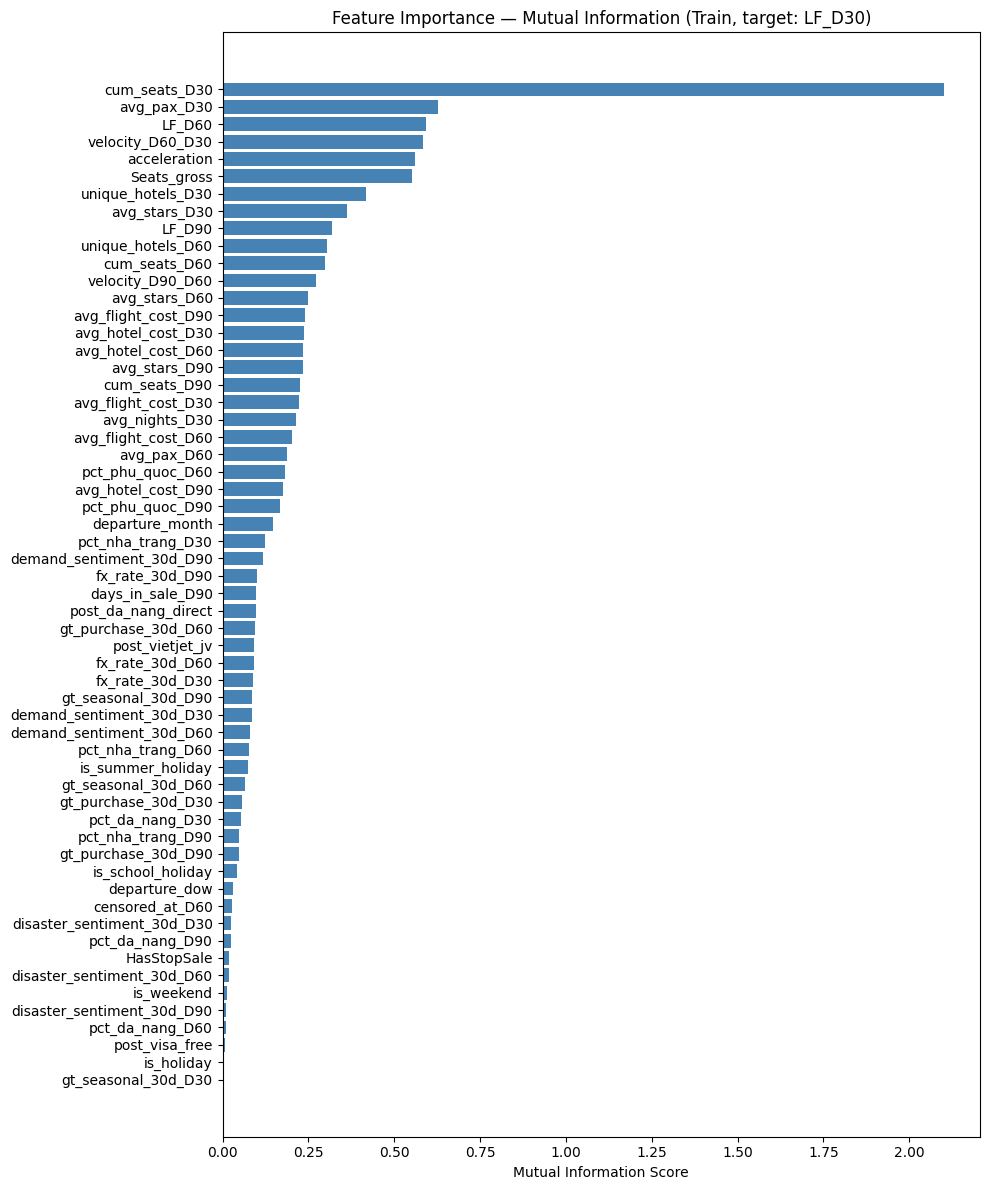

In [690]:
# Plot as horizontal bar chart
# Longest bar = most informative feature
plt.figure(figsize=(10, 12))
plt.barh(mi_df['feature'], mi_df['mi_score'], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance — Mutual Information (Train, target: LF_D30)')
plt.gca().invert_yaxis()  # most important feature at the top
plt.tight_layout()
plt.show()

In [691]:
# Features with score = 0 carry NO signal
zero_mi = mi_df[mi_df['mi_score'] == 0]['feature'].tolist()
print(zero_mi)

['is_holiday', 'gt_seasonal_30d_D30']


In [692]:
feature_cols_mi = [f for f in feature_cols_filtered
                      if f not in zero_mi]

print(f"Features after MI filter: {len(feature_cols_mi)}")
print(f"Removed: {zero_mi}")

Features after MI filter: 56
Removed: ['is_holiday', 'gt_seasonal_30d_D30']


In [693]:
# Confirm cum_seats_D30 and LF_D30 are strongly correlated
corr = df_curves[['cum_seats_D30', 'LF_D30', 'Seats_gross']].corr().round(3)
print(corr)

               cum_seats_D30  LF_D30  Seats_gross
cum_seats_D30          1.000   0.477        0.712
LF_D30                 0.477   1.000       -0.147
Seats_gross            0.712  -0.147        1.000


### Step 3: Tree Importance
We train a quick LightGBM model on train set and check which features it actually uses. Tree Importance (threshold < 5)
Removed N features with negligible contribution to model splits.

In [694]:
# Prepare data and use only final features
X_train = train[feature_cols_mi].select_dtypes(include='number').fillna(0)
y_train = train['LF_D30']

In [695]:
# Train a quick model, just for importance
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

LGBMRegressor(random_state=42)

In [696]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [701]:
# Features with < 5 importance
not_enough_imp = importance_df[importance_df['importance'] < 5]['feature'].tolist()
print(f"Features with < 5 tree importance: {len(not_enough_imp)}")
print(not_enough_imp)

Features with < 5 tree importance: 15
['post_da_nang_direct', 'is_summer_holiday', 'pct_da_nang_D60', 'pct_phu_quoc_D60', 'disaster_sentiment_30d_D30', 'disaster_sentiment_30d_D90', 'pct_phu_quoc_D90', 'post_vietjet_jv', 'is_school_holiday', 'HasStopSale', 'censored_at_D60', 'pct_da_nang_D90', 'is_weekend', 'post_visa_free', 'disaster_sentiment_30d_D60']


In [698]:
feature_cols_final = [f for f in feature_cols_mi
                      if f not in zero_imp]

print(f"Features after tree filter: {len(feature_cols_final)}")
print(f"Removed: {zero_imp}")

Features after tree filter: 41
Removed: ['post_da_nang_direct', 'is_summer_holiday', 'pct_da_nang_D60', 'pct_phu_quoc_D60', 'disaster_sentiment_30d_D30', 'disaster_sentiment_30d_D90', 'pct_phu_quoc_D90', 'post_vietjet_jv', 'is_school_holiday', 'HasStopSale', 'censored_at_D60', 'pct_da_nang_D90', 'is_weekend', 'post_visa_free', 'disaster_sentiment_30d_D60']


In [699]:
print(f"Final features: {len(feature_cols_final)}")
print(feature_cols_final)

Final features: 41
['cum_seats_D90', 'cum_seats_D60', 'cum_seats_D30', 'Seats_gross', 'LF_D90', 'LF_D60', 'days_in_sale_D90', 'avg_hotel_cost_D90', 'avg_stars_D90', 'avg_flight_cost_D90', 'pct_nha_trang_D90', 'avg_hotel_cost_D60', 'avg_stars_D60', 'avg_pax_D60', 'avg_flight_cost_D60', 'unique_hotels_D60', 'pct_nha_trang_D60', 'avg_hotel_cost_D30', 'avg_stars_D30', 'avg_nights_D30', 'avg_pax_D30', 'avg_flight_cost_D30', 'unique_hotels_D30', 'pct_nha_trang_D30', 'pct_da_nang_D30', 'velocity_D90_D60', 'velocity_D60_D30', 'acceleration', 'departure_month', 'departure_dow', 'fx_rate_30d_D90', 'fx_rate_30d_D60', 'fx_rate_30d_D30', 'gt_purchase_30d_D90', 'gt_seasonal_30d_D90', 'gt_purchase_30d_D60', 'gt_seasonal_30d_D60', 'gt_purchase_30d_D30', 'demand_sentiment_30d_D90', 'demand_sentiment_30d_D60', 'demand_sentiment_30d_D30']


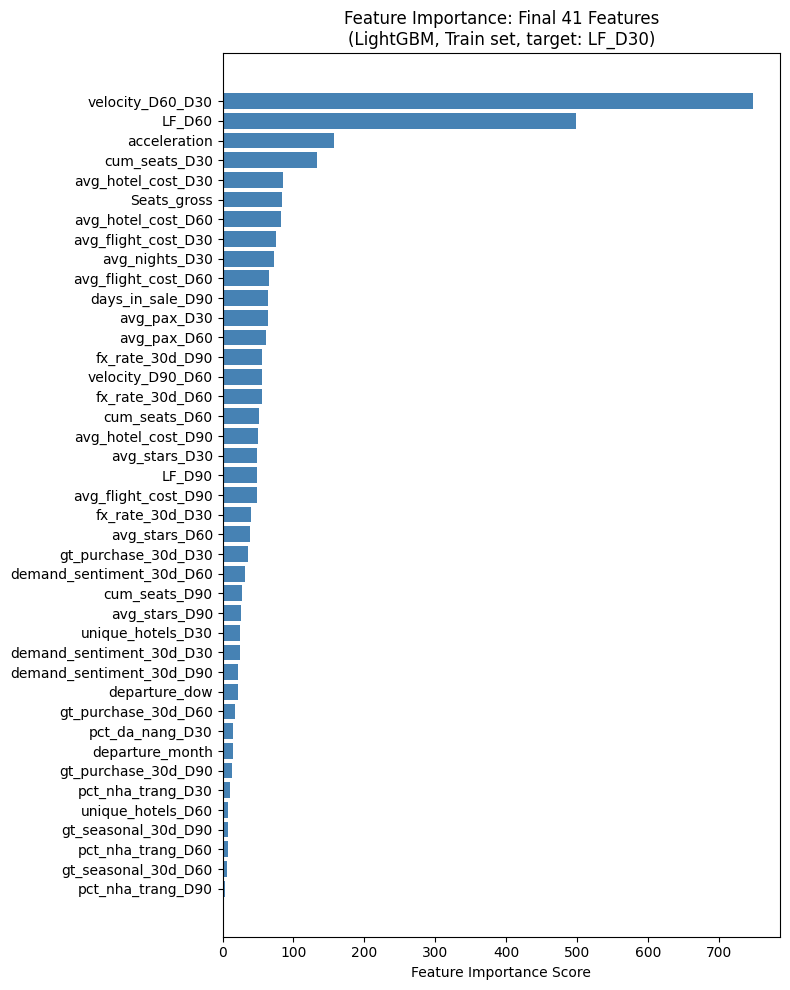

In [700]:
# Final importance plot
X_train_final = train[feature_cols_final].select_dtypes(include='number').fillna(0)
y_train = train['LF_D30']

model_final = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_final.fit(X_train_final, y_train)

importance_final = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': model_final.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(importance_final['feature'],
         importance_final['importance'],
         color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance: Final 41 Features\n(LightGBM, Train set, target: LF_D30)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Summary: Feature Selection
---
Three-step selection applied on TRAIN set only to prevent data leakage.

**Step 1: Collinearity filter (r > 0.90)**
Removed highly correlated features duplicating existing signals.

**Step 2: Mutual Information (score = 0)**
Removed features with no predictive signal for LF_D30.

**Step 3: Tree Importance (LightGBM, threshold < 5)**
Removed 15 features with negligible model contribution, including all disaster sentiment features and structural event dummies.

**Result:** 41 final features ready for model training.

**Key finding:** Top predictive features are velocity_D60_D30 and LF_D60. Booking momentum in the final 30 days carries the strongest predictive signal. Product mix features  (avg_hotel_cost, avg_stars, avg_flight_cost) survived
across all three windows, confirming that what customers book early predicts how well a flight will fill.